In [2]:
import pandas as pd
df=pd.read_csv('C:/Users/user/Desktop/졸업작품/인천e음_통합_일별.csv',encoding= 'utf-8')

In [3]:
value_columns = ['지역', '연매출 3억원 이하', '연매출 3억~30억원']

# 각 행의 값 조합을 튜플로 변환
df['value_combination'] = df[value_columns].apply(tuple, axis=1)

# 고유한 조합 추출
combinations = df['value_combination'].unique()

# 조합별 데이터프레임 생성 (전체 컬럼 유지)
combination_dfs = {}
for combo in combinations:
    # 해당 조합에 맞는 행 필터링, 모든 컬럼 포함
    df_combo = df[df['value_combination'] == combo].copy()
    combination_dfs[combo] = df_combo

# 임시 컬럼 삭제
df = df.drop(columns='value_combination')

# 결과 출력
for combo, df_combo in combination_dfs.items():
    print(f"\n조합 {combo} 데이터프레임:")
    print(df_combo)


조합 ('인천광역시 강화군', '10%', '10%') 데이터프레임:
              일자         지역  문화_취미_영화관       숙박       약국        연료  유통업영리_편의점  \
0     2020-07-01  인천광역시 강화군          0   231000  2583710   7298221    5559990   
1     2020-07-02  인천광역시 강화군          0   750000  3087700   7670624    6639050   
2     2020-07-03  인천광역시 강화군          0   277000  2654400   7568314    7248600   
3     2020-07-04  인천광역시 강화군          0  1017500  1880950   7682203    8740020   
4     2020-07-05  인천광역시 강화군          0   725600  1086400   4957154    7411110   
...          ...        ...        ...      ...      ...       ...        ...   
1699  2025-02-24  인천광역시 강화군      28000   356500  3462200  10081843    5819350   
1700  2025-02-25  인천광역시 강화군          0    78000  3298550  10563335    5599590   
1701  2025-02-26  인천광역시 강화군      12000    40000  2996240   9641517    5992610   
1702  2025-02-27  인천광역시 강화군          0    72500  3526940   8220834    6304982   
1703  2025-02-28  인천광역시 강화군          0   142600  2706120  10674013   

In [4]:
import pandas as pd
import re

# 파일 로드
file_path = 'C:/Users/user/Desktop/졸업작품/인천e음_통합_일별.csv'
df = pd.read_csv(file_path)

# 날짜 형식 변환
df['일자'] = pd.to_datetime(df['일자'])

# 캐시백 비율 숫자 추출
for column in ['연매출 3억원 이하', '연매출 3억~30억원', '연매출 30억원 초과']:
    df[column] = df[column].apply(lambda x: int(re.search(r'\d+', x).group()) if isinstance(x, str) else x)

# 지역 제외한 비율 조합 생성
value_columns = ['연매출 3억원 이하', '연매출 3억~30억원']
df['value_combination'] = df[value_columns].apply(tuple, axis=1)

# 고유한 비율 조합 추출
combinations = df['value_combination'].unique()

# 조합별 데이터프레임 생성 (전체 컬럼 유지)
combination_dfs = {}
for combo in combinations:
    # 해당 조합에 맞는 행 필터링, 모든 컬럼 포함
    df_combo = df[df['value_combination'] == combo].drop(columns='value_combination').copy()
    combination_dfs[combo] = df_combo

print("✅ 비율 조합별 데이터프레임 생성 완료!")
print(f"총 비율 조합 수: {len(combination_dfs)}")


✅ 비율 조합별 데이터프레임 생성 완료!
총 비율 조합 수: 4


In [5]:
combo_key = (10, 10)
df_10=combination_dfs[combo_key]

combo_key = (10, 7)
df_7=combination_dfs[combo_key]

combo_key = (10, 5)
df_5=combination_dfs[combo_key]

# 5% 모델


In [ ]:


import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib

# 한글 폰트 설정 (필요 시 경로 수정)
font_location = 'C:\\Windows\\Fonts\\Hancom Gothic Regular.ttf'
font_name = fm.FontProperties(fname=font_location).get_name()
matplotlib.rc('font', family=font_name)

# df 설정 (5%, 7%, 10% 선택 가능)
df = df_5

# 지역 목록
regions = df['지역'].unique()

# 지역별 모델링
for region in regions:
    # 해당 지역 데이터 필터링
    data = df[df['지역'] == region].copy()

    # 날짜 정렬
    data['일자'] = pd.to_datetime(data['일자'])
    data = data.sort_values('일자')

    # 피처 엔지니어링
    data['ma_7'] = data['전체금액'].rolling(window=7, min_periods=1).mean()
    data['ma_30'] = data['전체금액'].rolling(window=15, min_periods=1).mean()
    data['ma_90'] = data['전체금액'].rolling(window=30, min_periods=1).mean()
    data['std_7'] = data['전체금액'].rolling(window=7, min_periods=1).std()
    data['range_7'] = data['전체금액'].rolling(window=7).max() - data['전체금액'].rolling(window=7).min()
    data['lag_1'] = data['전체금액'].shift(1)
    data['lag_3'] = data['전체금액'].shift(3)
    data['lag_30'] = data['전체금액'].shift(30)
    data['change_rate'] = data['전체금액'].pct_change().fillna(0)
    data['month'] = data['일자'].dt.month
    data['day_of_week'] = data['일자'].dt.dayofweek
    data['is_weekend'] = data['day_of_week'].isin([5, 6]).astype(int)

    # 결측치 처리
    data.fillna(0, inplace=True)

    # 타겟 설정
    target = '전체금액'
    features = [col for col in data.columns if col not in [target, '지역', 'value_combination', 'lpf_trend', '금액_deviation_30', '평년_월별_차이']]
    
    # 범주형 피처 선택 (지역 제외)
    categorical_features = [col for col in data.select_dtypes(include='object').columns if col in features]

    # 데이터가 너무 작으면 스킵
    if len(data) < 10 or data[target].nunique() <= 1:
        print(f"스킵: 지역 {region} (데이터 부족)")
        continue

    # 데이터 분할
    split_idx = int(len(data) * 0.8)
    X_train = data[features].iloc[:split_idx]
    X_valid = data[features].iloc[split_idx:]
    y_train = data[target].iloc[:split_idx]
    y_valid = data[target].iloc[split_idx:]

    # Pool 생성
    train_pool = Pool(X_train, y_train, cat_features=categorical_features)
    valid_pool = Pool(X_valid, y_valid, cat_features=categorical_features)

    # 모델 학습
    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.03,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        early_stopping_rounds=50,
        verbose=100
    )

    model.fit(train_pool, eval_set=valid_pool)

    # 예측
    y_pred = model.predict(X_valid)

    # 일자 기준 정렬
    X_valid = X_valid.copy()
    X_valid['일자'] = data['일자'].iloc[split_idx:]
    sorted_idx = X_valid['일자'].argsort()
    X_valid = X_valid.iloc[sorted_idx]
    y_valid = y_valid.iloc[sorted_idx]
    y_pred = y_pred[sorted_idx]

    # RMSE 계산
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

    # MAPE 계산
    mape = np.mean(np.abs((y_valid - y_pred) / y_valid)) * 100

    print(f"[지역 {region}] Validation RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")


    # 시각화
    plt.figure(figsize=(10, 6))
    plt.plot(X_valid['일자'], y_valid.values, label='실제값', marker='o')
    plt.plot(X_valid['일자'], y_pred, label='예측값', marker='x')
    plt.title(f"지역 {region} 10% 5% - 실제 vs 예측 (RMSE: {rmse:.2f}, MAPE: {mape:.2f}%)")
    plt.xlabel("일자")
    plt.ylabel("전체금액")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib

# 한글 폰트 설정
font_location = 'C:\\Windows\\Fonts\\Hancom Gothic Regular.ttf'
font_name = fm.FontProperties(fname=font_location).get_name()
matplotlib.rc('font', family=font_name)

# 전체 데이터 불러오기
df_all = pd.read_csv('C:/Users/user/Desktop/졸업작품/인천e음_통합_일별.csv', encoding='utf-8')
df_all['일자'] = pd.to_datetime(df_all['일자'])

# 5%만 선택해서 학습에 사용할 데이터 지정
df = df_5

regions = df['지역'].unique()
trained_models = {}  # ✅ 모델 저장용

for region in regions:
    data = df[df['지역'] == region].copy()
    data = data.sort_values('일자')

    # 피처 엔지니어링
    data['ma_7'] = data['전체금액'].rolling(7, min_periods=1).mean()
    data['ma_30'] = data['전체금액'].rolling(15, min_periods=1).mean()
    data['ma_90'] = data['전체금액'].rolling(30, min_periods=1).mean()
    data['std_7'] = data['전체금액'].rolling(7, min_periods=1).std()
    data['range_7'] = data['전체금액'].rolling(7).max() - data['전체금액'].rolling(7).min()
    data['lag_1'] = data['전체금액'].shift(1)
    data['lag_3'] = data['전체금액'].shift(3)
    data['lag_30'] = data['전체금액'].shift(30)
    data['change_rate'] = data['전체금액'].pct_change().fillna(0)
    data['month'] = data['일자'].dt.month
    data['day_of_week'] = data['일자'].dt.dayofweek
    data['is_weekend'] = data['day_of_week'].isin([5, 6]).astype(int)

    data.fillna(0, inplace=True)

    target = '전체금액'
    features = [col for col in data.columns if col not in [target, '지역', 'value_combination', 'lpf_trend', '금액_deviation_30', '평년_월별_차이']]
    categorical_features = [col for col in data.select_dtypes(include='object').columns if col in features]

    if len(data) < 10 or data[target].nunique() <= 1:
        print(f"[{region}] ❌ 데이터 부족")
        continue

    split_idx = int(len(data) * 0.8)
    X_train, X_valid = data[features].iloc[:split_idx], data[features].iloc[split_idx:]
    y_train, y_valid = data[target].iloc[:split_idx], data[target].iloc[split_idx:]

    train_pool = Pool(X_train, y_train, cat_features=categorical_features)
    valid_pool = Pool(X_valid, y_valid, cat_features=categorical_features)

    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.03,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        early_stopping_rounds=50,
        verbose=100
    )
    model.fit(train_pool, eval_set=valid_pool)
    trained_models[region] = model  # ✅ 모델 저장

    y_pred = model.predict(X_valid)
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    mape = np.mean(np.abs((y_valid - y_pred) / y_valid)) * 100
    print(f"[{region}] ✅ Validation RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

# ------------------------
# ✅ 전체 df로 2024년 이후 예측
# ------------------------

for region in regions:
    # 원본 전체 df에서 해당 지역 추출
    future_data = df_all[df_all['지역'] == region].copy()
    future_data['일자'] = pd.to_datetime(future_data['일자'])
    future_data = future_data.sort_values('일자')

    # 동일한 피처 엔지니어링 수행
    future_data['ma_7'] = future_data['전체금액'].rolling(7, min_periods=1).mean()
    future_data['ma_30'] = future_data['전체금액'].rolling(15, min_periods=1).mean()
    future_data['ma_90'] = future_data['전체금액'].rolling(30, min_periods=1).mean()
    future_data['std_7'] = future_data['전체금액'].rolling(7, min_periods=1).std()
    future_data['range_7'] = future_data['전체금액'].rolling(7).max() - future_data['전체금액'].rolling(7).min()
    future_data['lag_1'] = future_data['전체금액'].shift(1)
    future_data['lag_3'] = future_data['전체금액'].shift(3)
    future_data['lag_30'] = future_data['전체금액'].shift(30)
    future_data['change_rate'] = future_data['전체금액'].pct_change().fillna(0)
    future_data['month'] = future_data['일자'].dt.month
    future_data['day_of_week'] = future_data['일자'].dt.dayofweek
    future_data['is_weekend'] = future_data['day_of_week'].isin([5, 6]).astype(int)

    future_data.fillna(0, inplace=True)

    model = trained_models.get(region)
    if model is None:
        print(f"[{region}] ❌ 모델 없음")
        continue

    future_2024 = future_data[future_data['일자'] >= pd.to_datetime('2024-01-01')]

    if len(future_2024) < 5:
        print(f"[{region}] ⚠️ 2024년 이후 데이터 부족")
        continue

    X_test_2024 = future_2024[features]
    y_test_2024 = future_2024[target]
    y_pred_2024 = model.predict(X_test_2024)

    rmse_2024 = np.sqrt(mean_squared_error(y_test_2024, y_pred_2024))
    mape_2024 = np.mean(np.abs((y_test_2024 - y_pred_2024) / y_test_2024)) * 100

    print(f"[{region}] 📅 2024년 이후 예측 RMSE: {rmse_2024:.2f}, MAPE: {mape_2024:.2f}%")

    # 시각화
    plt.figure(figsize=(10, 6))
    plt.plot(future_2024['일자'], y_test_2024, label='실제값', marker='o')
    plt.plot(future_2024['일자'], y_pred_2024, label='예측값', marker='x')
    plt.title(f"[{region}] 2024년 이후 예측 (RMSE: {rmse_2024:.2f}, MAPE: {mape_2024:.2f}%)")
    plt.xlabel("일자")
    plt.ylabel("전체금액")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


0:	learn: 22072544.9077203	test: 19640428.2535766	best: 19640428.2535766 (0)	total: 37.3ms	remaining: 37.3s
100:	learn: 5681207.3728986	test: 5023760.3924265	best: 5023760.3924265 (100)	total: 4.58s	remaining: 40.7s
200:	learn: 2728250.8582084	test: 3782271.5996570	best: 3782271.5996570 (200)	total: 8.34s	remaining: 33.2s
300:	learn: 1631537.9100237	test: 3199355.1581251	best: 3199355.1581251 (300)	total: 12.2s	remaining: 28.4s
400:	learn: 1079791.9036178	test: 3016601.6198898	best: 3014812.6726249 (397)	total: 16s	remaining: 23.9s
500:	learn: 759547.1575637	test: 2897697.0645750	best: 2897697.0645750 (500)	total: 19.9s	remaining: 19.8s
600:	learn: 576213.6276497	test: 2831210.5816281	best: 2831011.0232900 (598)	total: 23.5s	remaining: 15.6s
700:	learn: 432114.0090290	test: 2813609.3361560	best: 2812543.2112969 (699)	total: 27s	remaining: 11.5s
800:	learn: 334206.3184334	test: 2792124.7231101	best: 2791730.9127011 (799)	total: 30.7s	remaining: 7.62s
900:	learn: 266189.6693234	test: 277

# 7% 모델

In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib

# 한글 폰트 설정 (필요 시 경로 수정)
font_location = 'C:\\Windows\\Fonts\\Hancom Gothic Regular.ttf'
font_name = fm.FontProperties(fname=font_location).get_name()
matplotlib.rc('font', family=font_name)

# df 설정 (5%, 7%, 10% 선택 가능)
df = df_7

# 지역 목록
regions = df['지역'].unique()

# 지역별 모델링
for region in regions:
    # 해당 지역 데이터 필터링
    data = df[df['지역'] == region].copy()

    # 날짜 정렬
    data['일자'] = pd.to_datetime(data['일자'])
    data = data.sort_values('일자')

    # 피처 엔지니어링
    data['ma_7'] = data['전체금액'].rolling(window=7, min_periods=1).mean()
    data['ma_30'] = data['전체금액'].rolling(window=15, min_periods=1).mean()
    data['ma_90'] = data['전체금액'].rolling(window=30, min_periods=1).mean()
    data['std_7'] = data['전체금액'].rolling(window=7, min_periods=1).std()
    data['range_7'] = data['전체금액'].rolling(window=7).max() - data['전체금액'].rolling(window=7).min()
    data['lag_1'] = data['전체금액'].shift(1)
    data['lag_3'] = data['전체금액'].shift(3)
    data['lag_30'] = data['전체금액'].shift(30)
    data['change_rate'] = data['전체금액'].pct_change().fillna(0)
    data['month'] = data['일자'].dt.month
    data['day_of_week'] = data['일자'].dt.dayofweek
    data['is_weekend'] = data['day_of_week'].isin([5, 6]).astype(int)

    # 결측치 처리
    data.fillna(0, inplace=True)

    # 타겟 설정
    target = '전체금액'
    features = [col for col in data.columns if col not in [target, '지역', 'value_combination', 'lpf_trend', '금액_deviation_30', '평년_월별_차이']]
    
    # 범주형 피처 선택 (지역 제외)
    categorical_features = [col for col in data.select_dtypes(include='object').columns if col in features]

    # 데이터가 너무 작으면 스킵
    if len(data) < 10 or data[target].nunique() <= 1:
        print(f"스킵: 지역 {region} (데이터 부족)")
        continue

    # 데이터 분할
    split_idx = int(len(data) * 0.8)
    X_train = data[features].iloc[:split_idx]
    X_valid = data[features].iloc[split_idx:]
    y_train = data[target].iloc[:split_idx]
    y_valid = data[target].iloc[split_idx:]

    # Pool 생성
    train_pool = Pool(X_train, y_train, cat_features=categorical_features)
    valid_pool = Pool(X_valid, y_valid, cat_features=categorical_features)

    # 모델 학습
    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.03,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        early_stopping_rounds=50,
        verbose=100
    )

    model.fit(train_pool, eval_set=valid_pool)

    # 예측
    y_pred = model.predict(X_valid)

    # 일자 기준 정렬
    X_valid = X_valid.copy()
    X_valid['일자'] = data['일자'].iloc[split_idx:]
    sorted_idx = X_valid['일자'].argsort()
    X_valid = X_valid.iloc[sorted_idx]
    y_valid = y_valid.iloc[sorted_idx]
    y_pred = y_pred[sorted_idx]

    # RMSE 계산
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

    # MAPE 계산
    mape = np.mean(np.abs((y_valid - y_pred) / y_valid)) * 100

    print(f"[지역 {region}] Validation RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

    # 시각화
    plt.figure(figsize=(10, 6))
    plt.plot(X_valid['일자'], y_valid.values, label='실제값', marker='o')
    plt.plot(X_valid['일자'], y_pred, label='예측값', marker='x')
    plt.title(f"지역 {region} 10% 5% - 실제 vs 예측 (RMSE: {rmse:.2f}, MAPE: {mape:.2f}%)")
    plt.xlabel("일자")
    plt.ylabel("전체금액")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# 10% 모델

In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib

# 한글 폰트 설정 (필요 시 경로 수정)
font_location = 'C:\\Windows\\Fonts\\Hancom Gothic Regular.ttf'
font_name = fm.FontProperties(fname=font_location).get_name()
matplotlib.rc('font', family=font_name)

# df 설정 (5%, 7%, 10% 선택 가능)
df = df_10

# 지역 목록
regions = df['지역'].unique()

# 지역별 모델링
for region in regions:
    # 해당 지역 데이터 필터링
    data = df[df['지역'] == region].copy()

    # 날짜 정렬
    data['일자'] = pd.to_datetime(data['일자'])
    data = data.sort_values('일자')

    # 피처 엔지니어링
    data['ma_7'] = data['전체금액'].rolling(window=7, min_periods=1).mean()
    data['ma_30'] = data['전체금액'].rolling(window=15, min_periods=1).mean()
    data['ma_90'] = data['전체금액'].rolling(window=30, min_periods=1).mean()
    data['std_7'] = data['전체금액'].rolling(window=7, min_periods=1).std()
    data['range_7'] = data['전체금액'].rolling(window=7).max() - data['전체금액'].rolling(window=7).min()
    data['lag_1'] = data['전체금액'].shift(1)
    data['lag_3'] = data['전체금액'].shift(3)
    data['lag_30'] = data['전체금액'].shift(30)
    data['change_rate'] = data['전체금액'].pct_change().fillna(0)
    data['month'] = data['일자'].dt.month
    data['day_of_week'] = data['일자'].dt.dayofweek
    data['is_weekend'] = data['day_of_week'].isin([5, 6]).astype(int)

    # 결측치 처리
    data.fillna(0, inplace=True)

    # 타겟 설정
    target = '전체금액'
    features = [col for col in data.columns if col not in [target, '지역', 'value_combination', 'lpf_trend', '금액_deviation_30', '평년_월별_차이']]
    
    # 범주형 피처 선택 (지역 제외)
    categorical_features = [col for col in data.select_dtypes(include='object').columns if col in features]

    # 데이터가 너무 작으면 스킵
    if len(data) < 10 or data[target].nunique() <= 1:
        print(f"스킵: 지역 {region} (데이터 부족)")
        continue

    # 데이터 분할
    split_idx = int(len(data) * 0.8)
    X_train = data[features].iloc[:split_idx]
    X_valid = data[features].iloc[split_idx:]
    y_train = data[target].iloc[:split_idx]
    y_valid = data[target].iloc[split_idx:]

    # Pool 생성
    train_pool = Pool(X_train, y_train, cat_features=categorical_features)
    valid_pool = Pool(X_valid, y_valid, cat_features=categorical_features)

    # 모델 학습
    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.03,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        early_stopping_rounds=50,
        verbose=100
    )

    model.fit(train_pool, eval_set=valid_pool)

    # 예측
    y_pred = model.predict(X_valid)

    # 일자 기준 정렬
    X_valid = X_valid.copy()
    X_valid['일자'] = data['일자'].iloc[split_idx:]
    sorted_idx = X_valid['일자'].argsort()
    X_valid = X_valid.iloc[sorted_idx]
    y_valid = y_valid.iloc[sorted_idx]
    y_pred = y_pred[sorted_idx]

    # RMSE 계산
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

    # MAPE 계산
    mape = np.mean(np.abs((y_valid - y_pred) / y_valid)) * 100

    print(f"[지역 {region}] Validation RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

    # 시각화
    plt.figure(figsize=(10, 6))
    plt.plot(X_valid['일자'], y_valid.values, label='실제값', marker='o')
    plt.plot(X_valid['일자'], y_pred, label='예측값', marker='x')
    plt.title(f"지역 {region} 10% 5% - 실제 vs 예측 (RMSE: {rmse:.2f}, MAPE: {mape:.2f}%)")
    plt.xlabel("일자")
    plt.ylabel("전체금액")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


0:	learn: 176467574.0249431	test: 85741300.3625544	best: 85741300.3625544 (0)	total: 31.8ms	remaining: 31.8s
100:	learn: 21535206.0123336	test: 35476533.4151382	best: 35476533.4151382 (100)	total: 3.06s	remaining: 27.2s
200:	learn: 8247258.7111520	test: 28248036.3862305	best: 28248036.3862305 (200)	total: 5.93s	remaining: 23.6s
300:	learn: 6089363.2795291	test: 26954318.0504060	best: 26954318.0504060 (300)	total: 8.62s	remaining: 20s
400:	learn: 4508536.1934960	test: 26177146.1446444	best: 26164764.0036543 (398)	total: 11.2s	remaining: 16.7s
500:	learn: 3487078.6271235	test: 25798532.8559319	best: 25798532.8559319 (500)	total: 14.1s	remaining: 14.1s
600:	learn: 2748272.1939024	test: 25599832.9981629	best: 25599611.1609495 (598)	total: 17.9s	remaining: 11.9s
700:	learn: 2272309.3153155	test: 25459343.9388420	best: 25455484.1962479 (691)	total: 20.6s	remaining: 8.8s
800:	learn: 1920953.4630304	test: 25269305.7747569	best: 25269199.2469308 (799)	total: 23.4s	remaining: 5.81s
900:	learn: 1

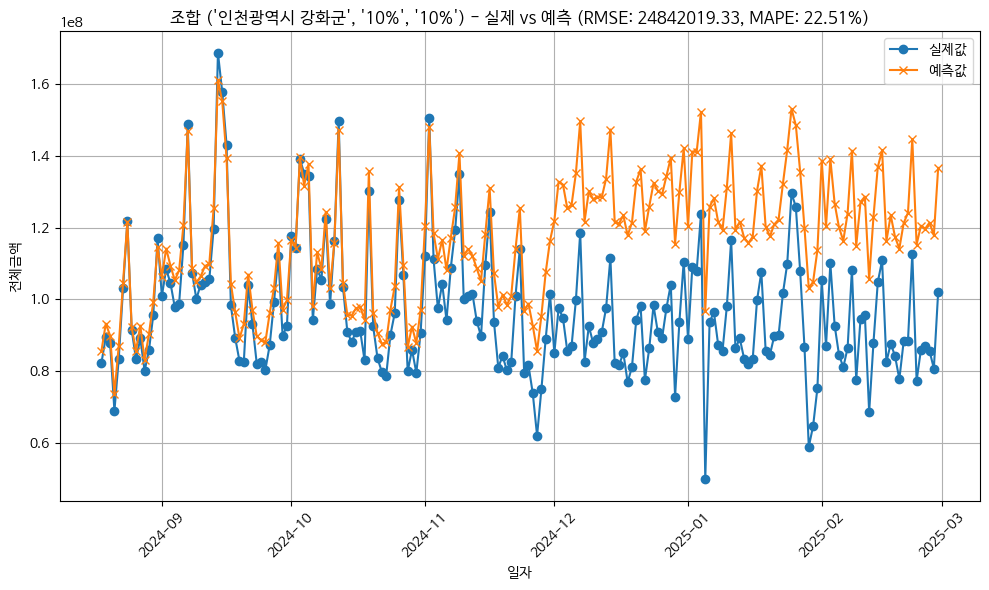

0:	learn: 36765161.0851596	test: 52836727.4825580	best: 52836727.4825580 (0)	total: 18.4ms	remaining: 18.4s
100:	learn: 9876311.4478213	test: 25808123.6992046	best: 25808123.6992046 (100)	total: 2.57s	remaining: 22.9s
200:	learn: 3666659.8699002	test: 19294323.7863925	best: 19294323.7863925 (200)	total: 5.29s	remaining: 21s
300:	learn: 1564999.6367453	test: 16813105.9223755	best: 16813105.9223755 (300)	total: 8.35s	remaining: 19.4s
400:	learn: 802306.6105519	test: 16059861.3831442	best: 16059861.3831442 (400)	total: 11.3s	remaining: 16.9s
500:	learn: 444894.3743325	test: 15634242.8525803	best: 15634242.8525803 (500)	total: 14.5s	remaining: 14.5s
600:	learn: 285509.5861018	test: 15552707.2102379	best: 15552707.2102379 (600)	total: 17.6s	remaining: 11.7s
700:	learn: 175447.0168301	test: 15499648.6913421	best: 15498562.8560572 (690)	total: 20.5s	remaining: 8.76s
800:	learn: 125455.7599337	test: 15485855.5450242	best: 15485410.7909757 (795)	total: 23.2s	remaining: 5.76s
900:	learn: 81441.0

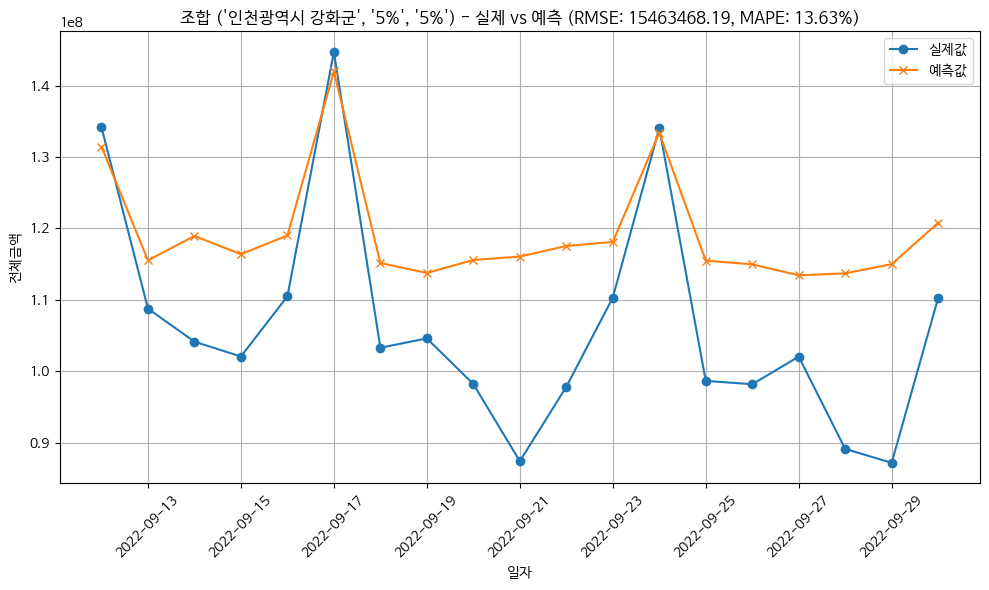

0:	learn: 22070530.9837491	test: 19611498.6620203	best: 19611498.6620203 (0)	total: 22ms	remaining: 21.9s
100:	learn: 5464347.9088719	test: 4505225.6206902	best: 4505225.6206902 (100)	total: 2.5s	remaining: 22.2s
200:	learn: 2741793.0812040	test: 3796361.5796970	best: 3796361.5796970 (200)	total: 5.28s	remaining: 21s
300:	learn: 1663090.5561455	test: 3471281.7739113	best: 3470837.6873393 (299)	total: 7.91s	remaining: 18.4s
400:	learn: 1108474.5441206	test: 3233702.6311397	best: 3232086.8744285 (394)	total: 10.9s	remaining: 16.3s
500:	learn: 774689.4622733	test: 3148553.4733402	best: 3146103.9868935 (496)	total: 14.4s	remaining: 14.4s
600:	learn: 604163.1526626	test: 3097199.3411732	best: 3094634.8383462 (596)	total: 17.9s	remaining: 11.9s
700:	learn: 461162.3570853	test: 3063272.2211159	best: 3063272.2211159 (700)	total: 22s	remaining: 9.37s
800:	learn: 360248.2101103	test: 3060610.2578706	best: 3054932.9403895 (760)	total: 26.3s	remaining: 6.53s
Stopped by overfitting detector  (50 it

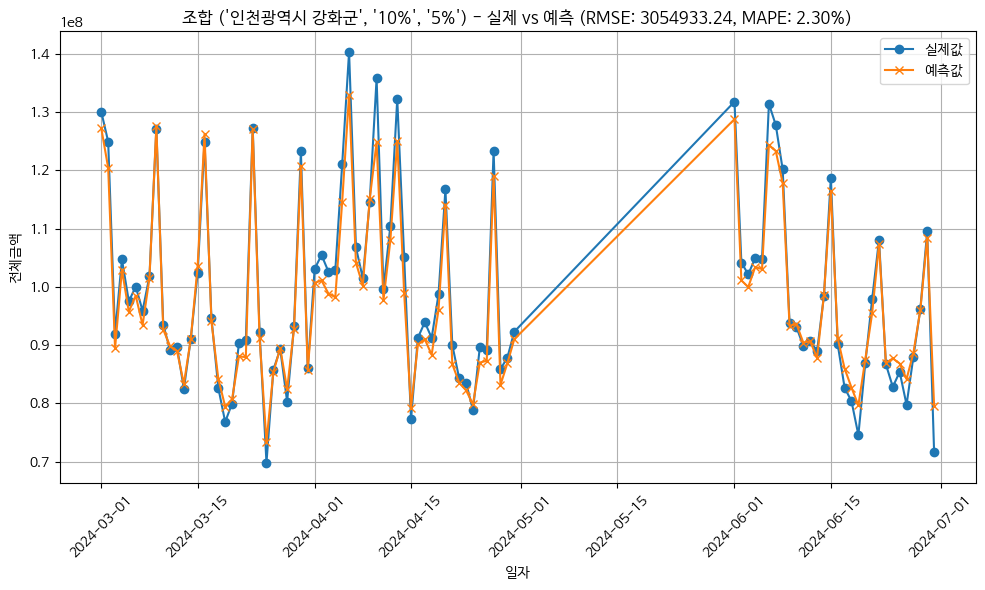

0:	learn: 33316876.0976101	test: 28510368.3631405	best: 28510368.3631405 (0)	total: 28.8ms	remaining: 28.8s
100:	learn: 8268860.8086147	test: 13507463.5953179	best: 13501384.7324765 (99)	total: 4.43s	remaining: 39.4s
200:	learn: 3751163.0375314	test: 11226849.8336908	best: 11226849.8336908 (200)	total: 8.86s	remaining: 35.2s
300:	learn: 2255051.1447730	test: 10540139.9713656	best: 10515788.0013137 (299)	total: 12.4s	remaining: 28.8s
400:	learn: 1439148.4014627	test: 10268223.5879393	best: 10263657.2422263 (399)	total: 16s	remaining: 23.9s
500:	learn: 967863.8140876	test: 10091650.4003110	best: 10091650.4003110 (500)	total: 20.5s	remaining: 20.4s
600:	learn: 653172.7684914	test: 9954744.8781552	best: 9952652.1016504 (597)	total: 30.1s	remaining: 20s
700:	learn: 457676.0932978	test: 9875375.3203045	best: 9875375.3203045 (700)	total: 34.5s	remaining: 14.7s
800:	learn: 328909.9958906	test: 9839419.8265208	best: 9839419.8265208 (800)	total: 38.5s	remaining: 9.56s
900:	learn: 245013.5621895	

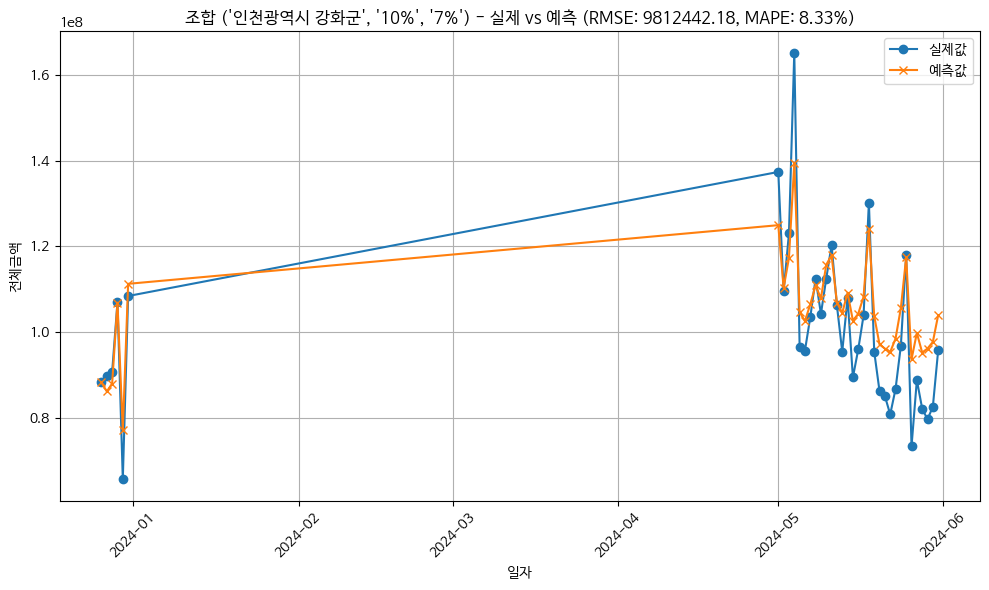

0:	learn: 225732658.2518229	test: 423966841.3166208	best: 423966841.3166208 (0)	total: 30ms	remaining: 30s
100:	learn: 44671618.4479035	test: 183739590.0398670	best: 183739590.0398670 (100)	total: 4.75s	remaining: 42.3s
200:	learn: 20578084.2802877	test: 161363975.6977016	best: 161363975.6977016 (200)	total: 8.91s	remaining: 35.4s
300:	learn: 12916307.9336282	test: 149785855.2294080	best: 149785855.2294080 (300)	total: 13.4s	remaining: 31.1s
400:	learn: 9691476.7748613	test: 148145487.7396325	best: 148079626.2603636 (399)	total: 17.4s	remaining: 26.1s
500:	learn: 7568774.6673761	test: 146548434.0065817	best: 146548434.0065817 (500)	total: 21.5s	remaining: 21.4s
600:	learn: 6169099.0062425	test: 146190732.0021582	best: 146148156.3496515 (583)	total: 26.1s	remaining: 17.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 146097481.1
bestIteration = 640

Shrink model to first 641 iterations.
[조합 ('인천광역시 계양구', '10%', '10%')] Validation RMSE: 146097480.63, MAPE: 10.26%


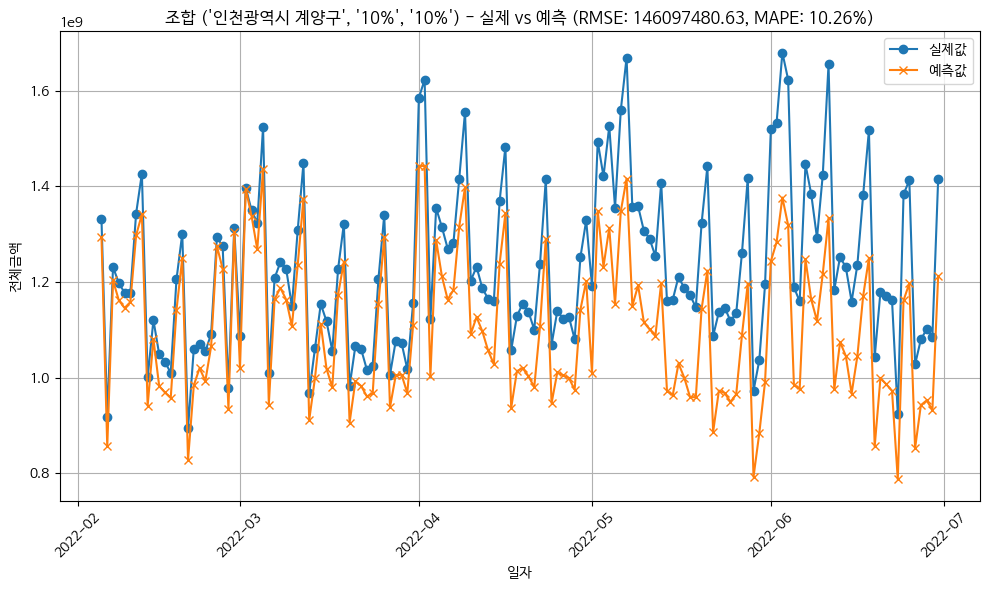

0:	learn: 221891575.6269839	test: 246848356.6315433	best: 246848356.6315433 (0)	total: 44ms	remaining: 43.9s
100:	learn: 66404938.2007948	test: 52096923.2084334	best: 52096923.2084334 (100)	total: 3.59s	remaining: 32s
200:	learn: 28848103.2712612	test: 23060014.8119538	best: 23060014.8119538 (200)	total: 7.38s	remaining: 29.3s
300:	learn: 12927323.8354295	test: 15371413.9753134	best: 15371413.9753134 (300)	total: 11.3s	remaining: 26.3s
400:	learn: 7720411.2301845	test: 13604467.4215519	best: 13604467.4215519 (400)	total: 15.3s	remaining: 22.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 13514599.34
bestIteration = 444

Shrink model to first 445 iterations.
[조합 ('인천광역시 계양구', '5%', '5%')] Validation RMSE: 13514593.95, MAPE: 1.45%


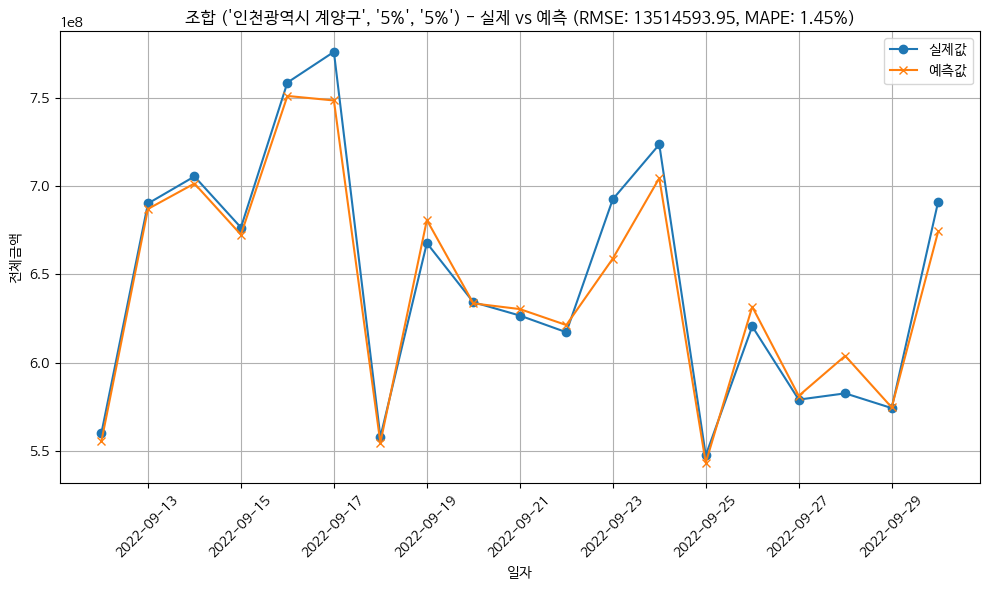

0:	learn: 121058608.4256359	test: 141573807.5375579	best: 141573807.5375579 (0)	total: 39ms	remaining: 39s
100:	learn: 28999945.5206241	test: 61276818.9288884	best: 61276818.9288884 (100)	total: 4.56s	remaining: 40.6s
200:	learn: 14114512.2010964	test: 48530246.1690691	best: 48530246.1690691 (200)	total: 8.54s	remaining: 34s
300:	learn: 8809163.4997273	test: 43720621.1337434	best: 43719779.5497819 (299)	total: 12.6s	remaining: 29.3s
400:	learn: 6228729.5542793	test: 42279028.4553241	best: 42279028.4553241 (400)	total: 16.5s	remaining: 24.7s
500:	learn: 4863107.5236696	test: 41265051.2859113	best: 41265051.2859113 (500)	total: 20s	remaining: 19.9s
600:	learn: 3902719.3862167	test: 40397031.0175912	best: 40388170.0945941 (598)	total: 23.5s	remaining: 15.6s
700:	learn: 3241867.3375829	test: 39800515.8095529	best: 39800515.8095529 (700)	total: 26.9s	remaining: 11.5s
800:	learn: 2728232.1009948	test: 39447707.6221344	best: 39443864.0300916 (799)	total: 30.6s	remaining: 7.6s
900:	learn: 2323

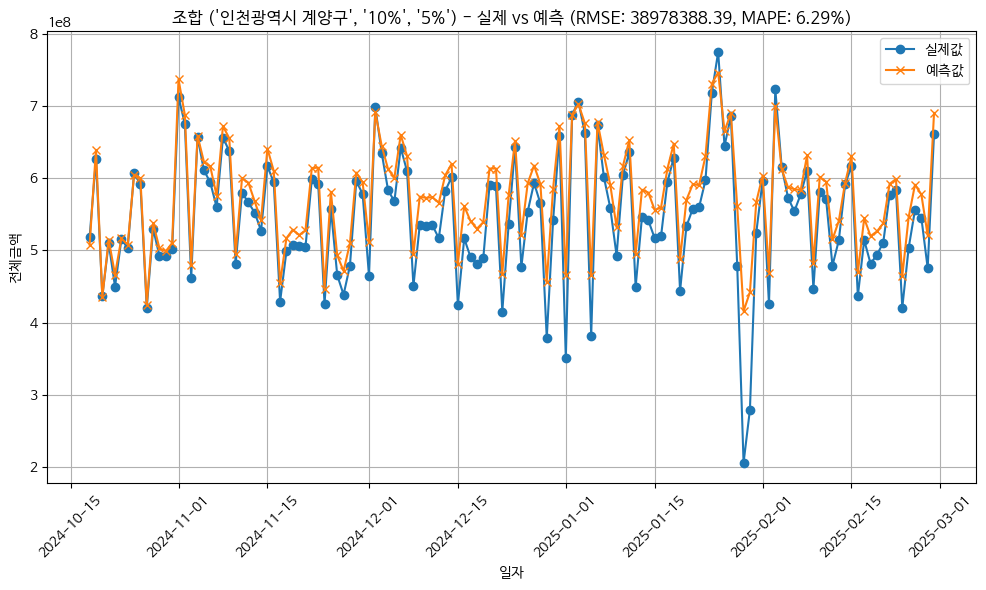

0:	learn: 188444950.3345132	test: 192773592.9239217	best: 192773592.9239217 (0)	total: 28.2ms	remaining: 28.2s
100:	learn: 57178335.7900240	test: 96028370.4964394	best: 96028370.4964394 (100)	total: 5.12s	remaining: 45.5s
200:	learn: 30097763.0956408	test: 78113286.7400763	best: 78113286.7400763 (200)	total: 9.09s	remaining: 36.1s
300:	learn: 16435445.1915110	test: 65886904.5295222	best: 65886904.5295222 (300)	total: 16.9s	remaining: 39.2s
400:	learn: 10093833.3685120	test: 59925827.4323301	best: 59925827.4323301 (400)	total: 20.6s	remaining: 30.7s
500:	learn: 6858220.0477354	test: 56977488.7918749	best: 56977488.7918749 (500)	total: 23.9s	remaining: 23.8s
600:	learn: 4297446.8777542	test: 55470291.2773202	best: 55470291.2773202 (600)	total: 26.8s	remaining: 17.8s
700:	learn: 2978281.6050173	test: 54742755.1635829	best: 54730967.2357495 (694)	total: 29.5s	remaining: 12.6s
800:	learn: 2123384.9678006	test: 54455692.0281491	best: 54455692.0281491 (800)	total: 32.7s	remaining: 8.13s
900:	

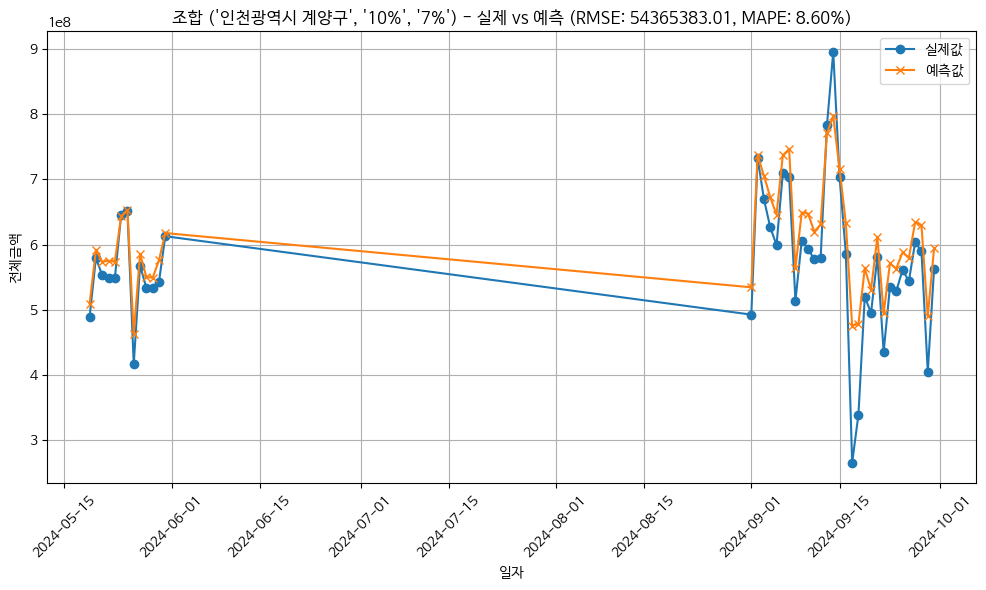

0:	learn: 535812737.2645572	test: 916234136.2384304	best: 916234136.2384304 (0)	total: 36.5ms	remaining: 36.5s
100:	learn: 96738139.6166269	test: 321668580.4144403	best: 321668580.4144403 (100)	total: 7.16s	remaining: 1m 3s
200:	learn: 40217803.2014491	test: 264764363.8045798	best: 264764363.8045798 (200)	total: 15.2s	remaining: 1m
300:	learn: 25428814.1924210	test: 247844953.6936872	best: 247380243.9157859 (293)	total: 23.6s	remaining: 54.8s
400:	learn: 19515145.1940068	test: 246209552.5706055	best: 246133346.1953245 (367)	total: 31.3s	remaining: 46.7s
500:	learn: 14971106.8390473	test: 244969658.5879233	best: 244826516.4126967 (496)	total: 37s	remaining: 36.8s
600:	learn: 12105240.1579052	test: 244442229.6941067	best: 244357787.4614370 (566)	total: 41.6s	remaining: 27.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 244357787.5
bestIteration = 566

Shrink model to first 567 iterations.
[조합 ('인천광역시 남동구', '10%', '10%')] Validation RMSE: 244357786.41, MAPE: 6.94%


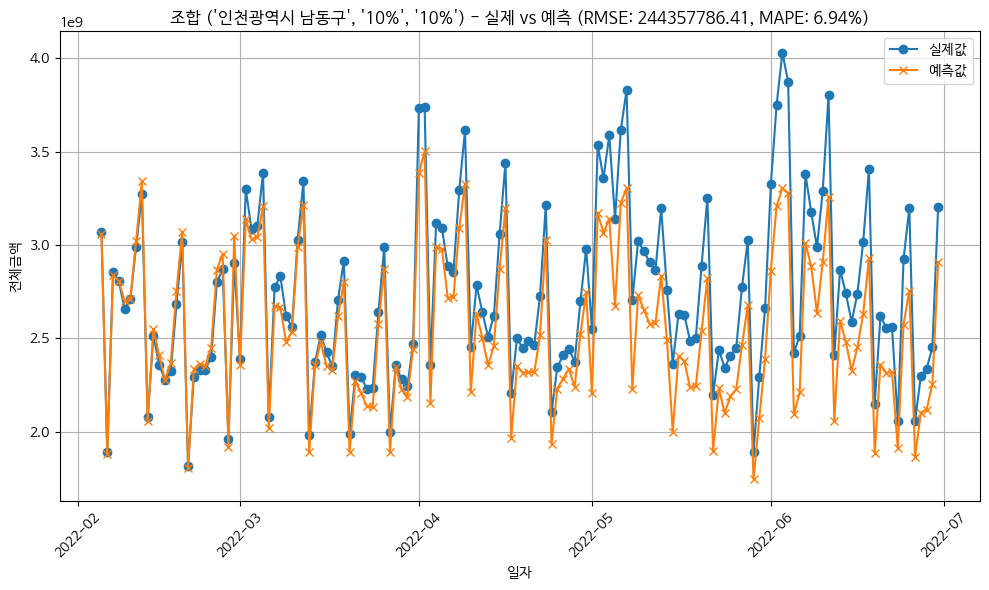

0:	learn: 503539031.1704620	test: 552484245.6079038	best: 552484245.6079038 (0)	total: 35.5ms	remaining: 35.5s
100:	learn: 141000099.8911917	test: 176250947.3199360	best: 176243118.2125133 (99)	total: 2.4s	remaining: 21.4s
200:	learn: 60202195.3199858	test: 101568441.6344641	best: 101568441.6344641 (200)	total: 5.46s	remaining: 21.7s
300:	learn: 29700486.9835413	test: 85640311.3459665	best: 85610615.2095441 (297)	total: 8.11s	remaining: 18.8s
400:	learn: 16440726.4948771	test: 78545320.0775107	best: 78545320.0775107 (400)	total: 10.9s	remaining: 16.2s
500:	learn: 9995059.1039890	test: 75639894.4806870	best: 75639894.4806870 (500)	total: 13.3s	remaining: 13.3s
600:	learn: 6697847.5206901	test: 74098468.3057149	best: 74098468.3057149 (600)	total: 16.5s	remaining: 10.9s
700:	learn: 4908184.6107034	test: 73535161.4388005	best: 73346121.0403916 (676)	total: 19.3s	remaining: 8.21s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 73346121.04
bestIteration = 676

Shrink model 

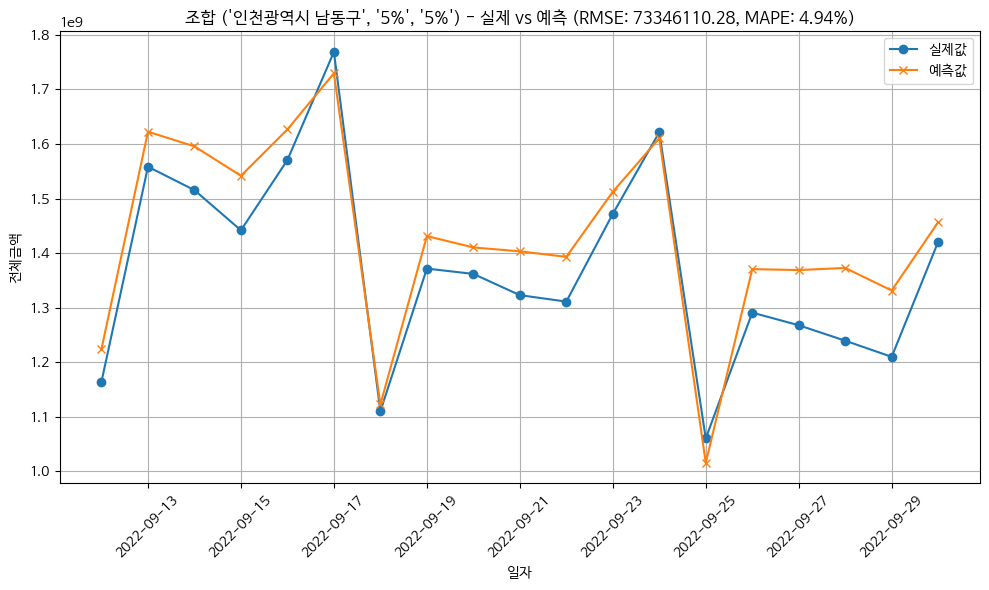

0:	learn: 303773356.7724319	test: 320464433.5621448	best: 320464433.5621448 (0)	total: 22.6ms	remaining: 22.6s
100:	learn: 62851928.6696208	test: 121064354.3374444	best: 121064354.3374444 (100)	total: 3.2s	remaining: 28.5s
200:	learn: 28957612.6029970	test: 92309760.3382755	best: 92298790.0446525 (199)	total: 6.15s	remaining: 24.4s
300:	learn: 17641191.3493043	test: 82740902.7756591	best: 82740902.7756591 (300)	total: 9.39s	remaining: 21.8s
400:	learn: 12570819.3086435	test: 79513409.9922722	best: 79513409.9922722 (400)	total: 12.3s	remaining: 18.4s
500:	learn: 9747993.7251792	test: 78395562.7784574	best: 78380695.6109442 (499)	total: 16.6s	remaining: 16.5s
600:	learn: 7772781.4075143	test: 76976264.4928429	best: 76976264.4928429 (600)	total: 22.1s	remaining: 14.7s
700:	learn: 6361170.7188688	test: 76416496.0302824	best: 76416496.0302824 (700)	total: 27.7s	remaining: 11.8s
800:	learn: 5394506.1973664	test: 76059739.2055821	best: 76057311.6998294 (799)	total: 35.2s	remaining: 8.75s
900:

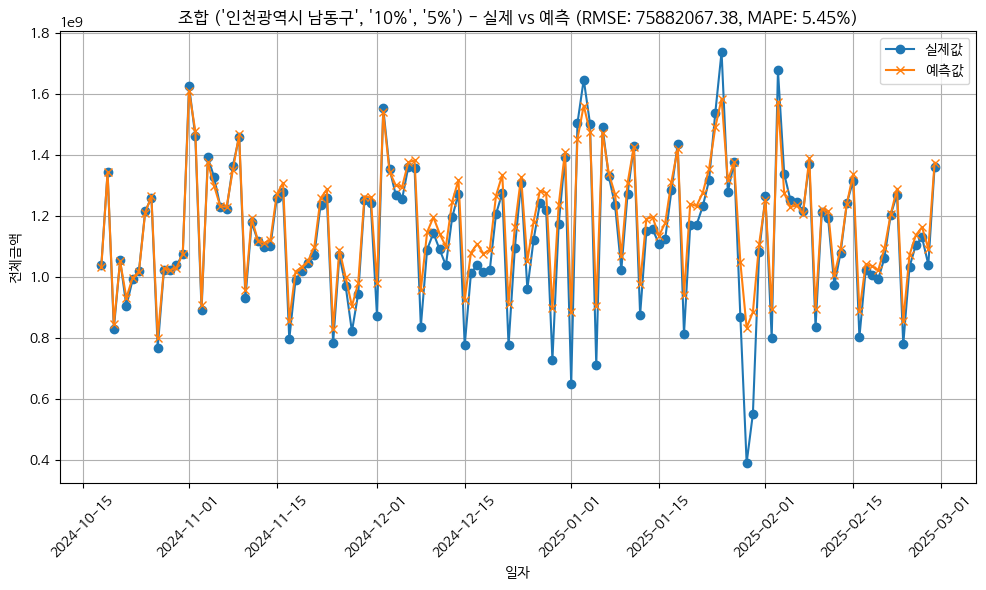

0:	learn: 501432310.4252589	test: 495877024.0733736	best: 495877024.0733736 (0)	total: 31.7ms	remaining: 31.7s
100:	learn: 130385241.3257317	test: 230912818.4718847	best: 230912818.4718847 (100)	total: 4.13s	remaining: 36.8s
200:	learn: 64651038.6129424	test: 181758531.3337005	best: 181758531.3337005 (200)	total: 10.8s	remaining: 43s
300:	learn: 37087848.5324369	test: 155620336.5940049	best: 155620336.5940049 (300)	total: 13.7s	remaining: 31.9s
400:	learn: 22444122.7426869	test: 142186408.3319590	best: 142186408.3319590 (400)	total: 17.6s	remaining: 26.3s
500:	learn: 15283285.3092904	test: 135242048.2267610	best: 135242048.2267610 (500)	total: 21.7s	remaining: 21.6s
600:	learn: 10889858.1646838	test: 132371939.8896464	best: 132371939.8896464 (600)	total: 26.3s	remaining: 17.4s
700:	learn: 7812583.4094098	test: 130969647.6431566	best: 130968559.9930697 (698)	total: 30.5s	remaining: 13s
800:	learn: 5769204.9410482	test: 130380100.3034787	best: 130380100.3034787 (800)	total: 34.5s	remaini

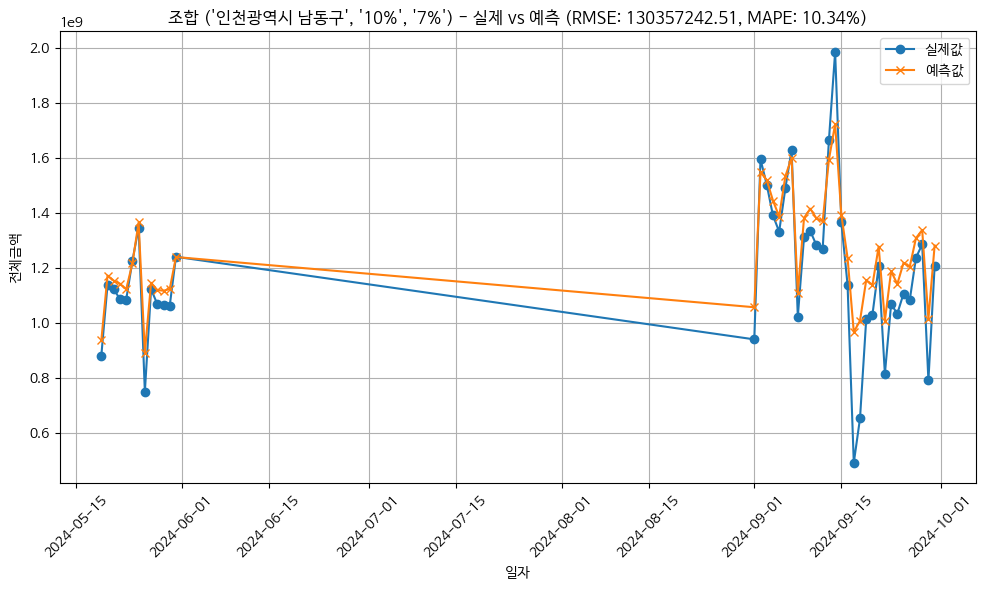

0:	learn: 46642720.1583887	test: 87394045.6945794	best: 87394045.6945794 (0)	total: 22.8ms	remaining: 22.8s
100:	learn: 8357415.9659024	test: 29195617.8199052	best: 29195617.8199052 (100)	total: 3.96s	remaining: 35.2s
200:	learn: 3584434.0440639	test: 21911892.5482341	best: 21911892.5482341 (200)	total: 7.69s	remaining: 30.6s
300:	learn: 2369556.0922133	test: 20206861.6193293	best: 20206861.6193293 (300)	total: 10.5s	remaining: 24.4s
400:	learn: 1804384.0825139	test: 19757128.9879641	best: 19756886.6141991 (399)	total: 13s	remaining: 19.5s
500:	learn: 1430091.7924096	test: 19512972.0011857	best: 19512972.0011857 (500)	total: 15.6s	remaining: 15.5s
600:	learn: 1167763.1460052	test: 19394472.1379008	best: 19391458.7235821 (598)	total: 18.3s	remaining: 12.2s
700:	learn: 959114.3712702	test: 19382263.3849805	best: 19368521.4790461 (673)	total: 21s	remaining: 8.97s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 19352938.73
bestIteration = 732

Shrink model to first 733 it

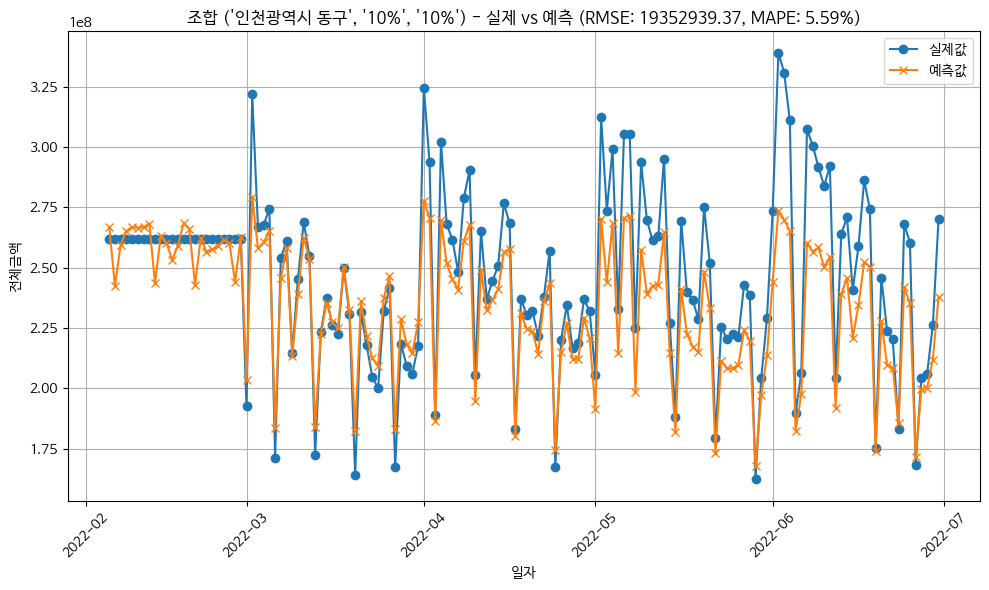

0:	learn: 50290627.9105649	test: 57136597.1280903	best: 57136597.1280903 (0)	total: 24.2ms	remaining: 24.1s
100:	learn: 14317432.1538196	test: 13213769.7396270	best: 13213769.7396270 (100)	total: 2.25s	remaining: 20s
200:	learn: 5903990.6728988	test: 5330792.1244570	best: 5330534.9609867 (199)	total: 4.48s	remaining: 17.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 5061896.79
bestIteration = 241

Shrink model to first 242 iterations.
[조합 ('인천광역시 동구', '5%', '5%')] Validation RMSE: 5061897.02, MAPE: 3.14%


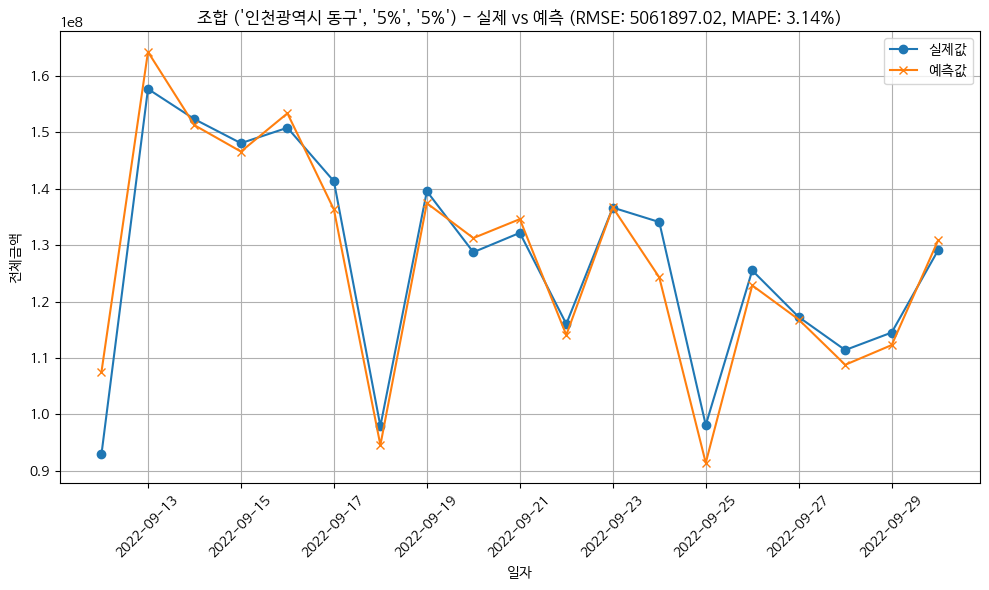

0:	learn: 27125350.9642581	test: 29944951.5001771	best: 29944951.5001771 (0)	total: 22.4ms	remaining: 22.4s
100:	learn: 6079746.0954329	test: 12487745.8076799	best: 12487745.8076799 (100)	total: 2.89s	remaining: 25.8s
200:	learn: 2812460.3681733	test: 9685764.6990136	best: 9685764.6990136 (200)	total: 5.68s	remaining: 22.6s
300:	learn: 1857155.8764084	test: 8782098.0546295	best: 8782098.0546295 (300)	total: 8.46s	remaining: 19.7s
400:	learn: 1353558.4292449	test: 8154036.5447177	best: 8154036.5447177 (400)	total: 11.5s	remaining: 17.1s
500:	learn: 1045174.5689473	test: 7769401.4870976	best: 7769401.4870976 (500)	total: 14.3s	remaining: 14.3s
600:	learn: 848624.3912081	test: 7620107.0323748	best: 7620089.1164377 (599)	total: 17.3s	remaining: 11.5s
700:	learn: 693738.5419998	test: 7526698.3080517	best: 7526294.7856262 (699)	total: 20.6s	remaining: 8.77s
800:	learn: 575116.8217604	test: 7459901.5188872	best: 7459901.5188872 (800)	total: 23.3s	remaining: 5.8s
900:	learn: 488298.7978188	tes

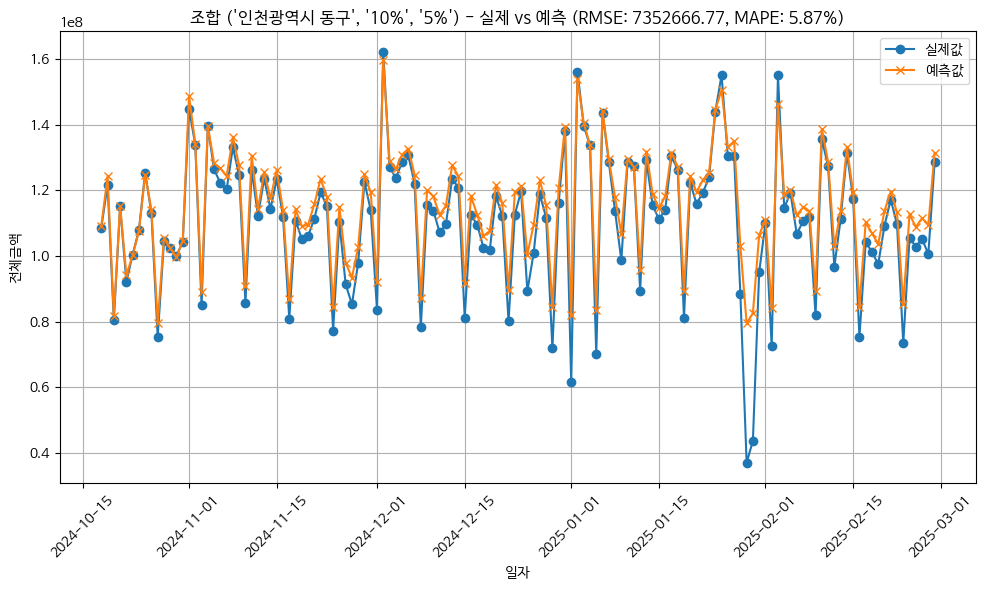

0:	learn: 40564593.3870918	test: 42748639.1753000	best: 42748639.1753000 (0)	total: 29.6ms	remaining: 29.6s
100:	learn: 11612299.8005056	test: 20985610.2898596	best: 20985610.2898596 (100)	total: 2.52s	remaining: 22.4s
200:	learn: 6177370.6732267	test: 17158461.2744951	best: 17158461.2744951 (200)	total: 5.38s	remaining: 21.4s
300:	learn: 3445453.3270246	test: 14835488.5629565	best: 14835488.5629565 (300)	total: 9.02s	remaining: 20.9s
400:	learn: 2125138.8537583	test: 13832760.5243633	best: 13832760.5243633 (400)	total: 15.3s	remaining: 22.8s
500:	learn: 1423129.1256007	test: 13259643.2201318	best: 13259643.2201318 (500)	total: 18.5s	remaining: 18.4s
600:	learn: 979487.1603738	test: 13021440.9596107	best: 13021440.9596107 (600)	total: 22.3s	remaining: 14.8s
700:	learn: 686591.7447308	test: 12885179.7517009	best: 12885179.7517009 (700)	total: 25.4s	remaining: 10.8s
800:	learn: 485648.5522729	test: 12829088.0098633	best: 12827862.5121158 (798)	total: 27.9s	remaining: 6.92s
900:	learn: 36

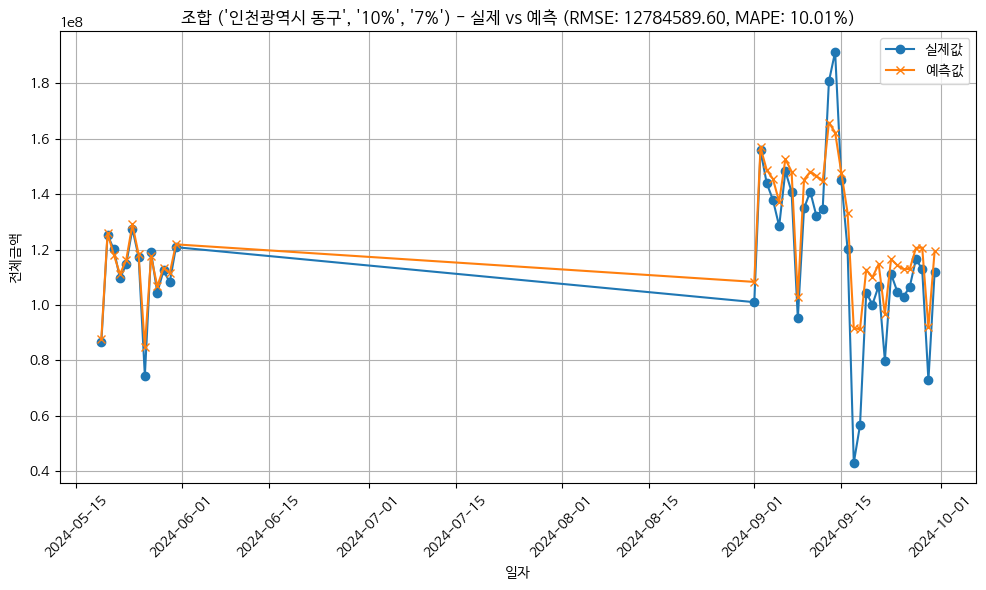

0:	learn: 318625930.6661350	test: 553930627.8172548	best: 553930627.8172548 (0)	total: 44ms	remaining: 44s
100:	learn: 57484243.2180241	test: 175015426.1039263	best: 175015426.1039263 (100)	total: 7.39s	remaining: 1m 5s
200:	learn: 24471456.0167419	test: 144199469.8334847	best: 144199469.8334847 (200)	total: 12.3s	remaining: 48.9s
300:	learn: 16452790.9085850	test: 136045060.0711783	best: 136044059.5451133 (298)	total: 16.5s	remaining: 38.4s
400:	learn: 12993489.6308060	test: 131029157.2637502	best: 131029157.2637502 (400)	total: 20.6s	remaining: 30.7s
500:	learn: 10234652.0650078	test: 130068695.2271309	best: 130030299.3616811 (499)	total: 24.3s	remaining: 24.2s
600:	learn: 8343760.9468856	test: 129944487.3805195	best: 129810498.0257859 (569)	total: 27.8s	remaining: 18.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 129810498
bestIteration = 569

Shrink model to first 570 iterations.
[조합 ('인천광역시 미추홀구', '10%', '10%')] Validation RMSE: 129810495.68, MAPE: 5.69%


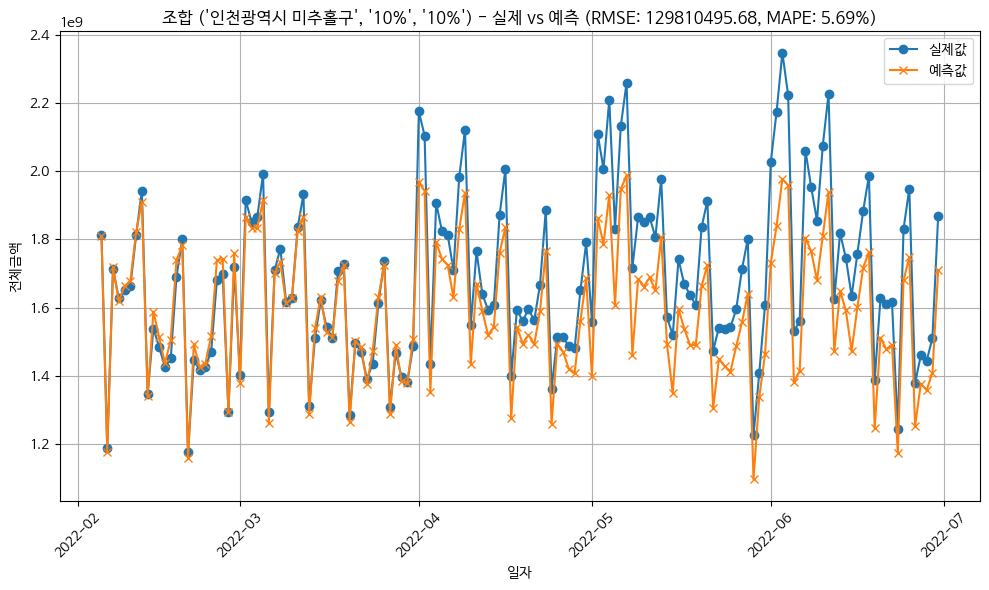

0:	learn: 311812066.9736181	test: 342971495.3782349	best: 342971495.3782349 (0)	total: 23.9ms	remaining: 23.9s
100:	learn: 82261418.0081479	test: 79880725.7079936	best: 79880725.7079936 (100)	total: 2.29s	remaining: 20.4s
200:	learn: 35462337.7731925	test: 35584645.0595780	best: 35584645.0595780 (200)	total: 4.98s	remaining: 19.8s
300:	learn: 18231809.2349666	test: 28091090.0975522	best: 28081373.4016197 (299)	total: 7.5s	remaining: 17.4s
400:	learn: 10492681.5312163	test: 27732517.9706155	best: 27549182.2440586 (355)	total: 10.1s	remaining: 15.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 27549182.24
bestIteration = 355

Shrink model to first 356 iterations.
[조합 ('인천광역시 미추홀구', '5%', '5%')] Validation RMSE: 27549177.64, MAPE: 2.49%


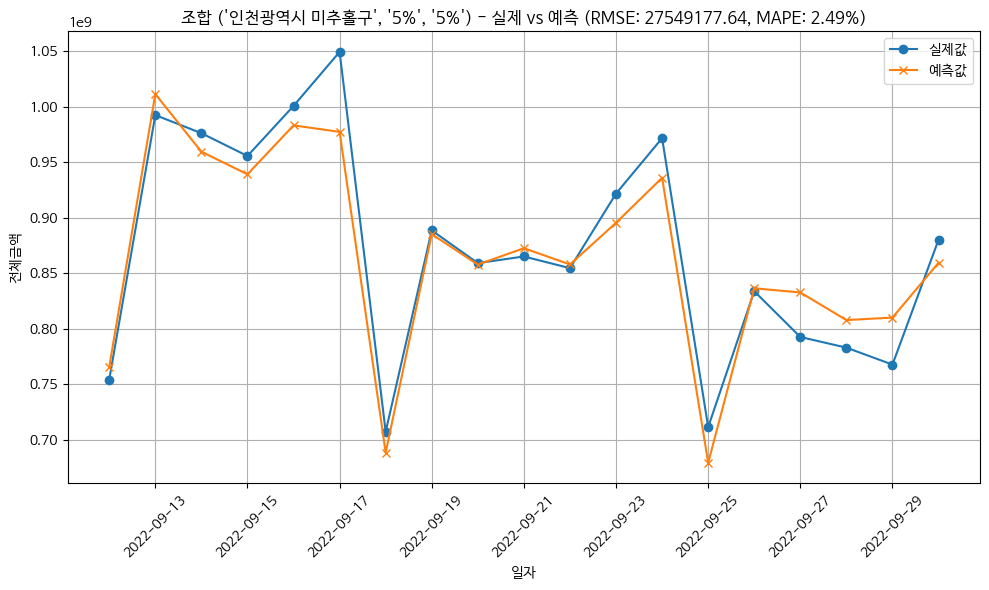

0:	learn: 165946727.9583221	test: 167890739.5586944	best: 167890739.5586944 (0)	total: 20.7ms	remaining: 20.6s
100:	learn: 37775847.4403462	test: 71118473.6618356	best: 71118473.6618356 (100)	total: 2.8s	remaining: 24.9s
200:	learn: 18346138.2798410	test: 56178200.4439972	best: 56178200.4439972 (200)	total: 5.68s	remaining: 22.6s
300:	learn: 11787430.6518465	test: 50560794.3749565	best: 50560794.3749565 (300)	total: 8.21s	remaining: 19.1s
400:	learn: 8431678.9617851	test: 48436826.4734744	best: 48413181.7397253 (398)	total: 10.9s	remaining: 16.3s
500:	learn: 6447437.5335653	test: 47003664.2014070	best: 47003664.2014070 (500)	total: 13.7s	remaining: 13.6s
600:	learn: 5068545.2974365	test: 46084826.5326660	best: 46074567.1473274 (596)	total: 16.3s	remaining: 10.8s
700:	learn: 4116188.8407564	test: 45529980.8303726	best: 45516239.0736771 (695)	total: 21.3s	remaining: 9.07s
800:	learn: 3415647.5090915	test: 45135816.7569057	best: 45135816.7569057 (800)	total: 25.8s	remaining: 6.41s
900:	le

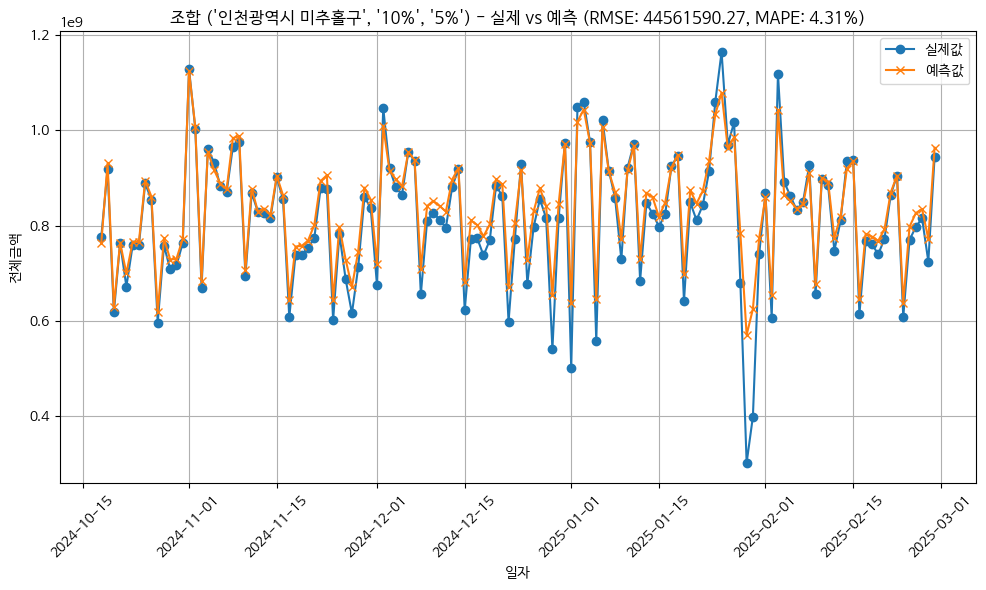

0:	learn: 267575690.4662042	test: 269575717.0393924	best: 269575717.0393924 (0)	total: 52.6ms	remaining: 52.5s
100:	learn: 77696219.0794726	test: 134573376.9040466	best: 134573376.9040466 (100)	total: 3.95s	remaining: 35.1s
200:	learn: 40196225.7005471	test: 109018699.2807820	best: 109018699.2807820 (200)	total: 6.78s	remaining: 27s
300:	learn: 22209386.7019672	test: 93623702.3906515	best: 93623702.3906515 (300)	total: 9.51s	remaining: 22.1s
400:	learn: 12988268.7972942	test: 84894849.9266272	best: 84894849.9266272 (400)	total: 13s	remaining: 19.5s
500:	learn: 8715195.7334243	test: 81397224.6442709	best: 81397224.6442709 (500)	total: 15.8s	remaining: 15.7s
600:	learn: 5970395.4375098	test: 80042109.5954350	best: 80042109.5954350 (600)	total: 18.4s	remaining: 12.2s
700:	learn: 4291783.4575332	test: 79131204.8944121	best: 79125154.2511622 (698)	total: 20.9s	remaining: 8.9s
800:	learn: 3170646.9273618	test: 78684925.5648614	best: 78684925.5648614 (800)	total: 24s	remaining: 5.96s
900:	lea

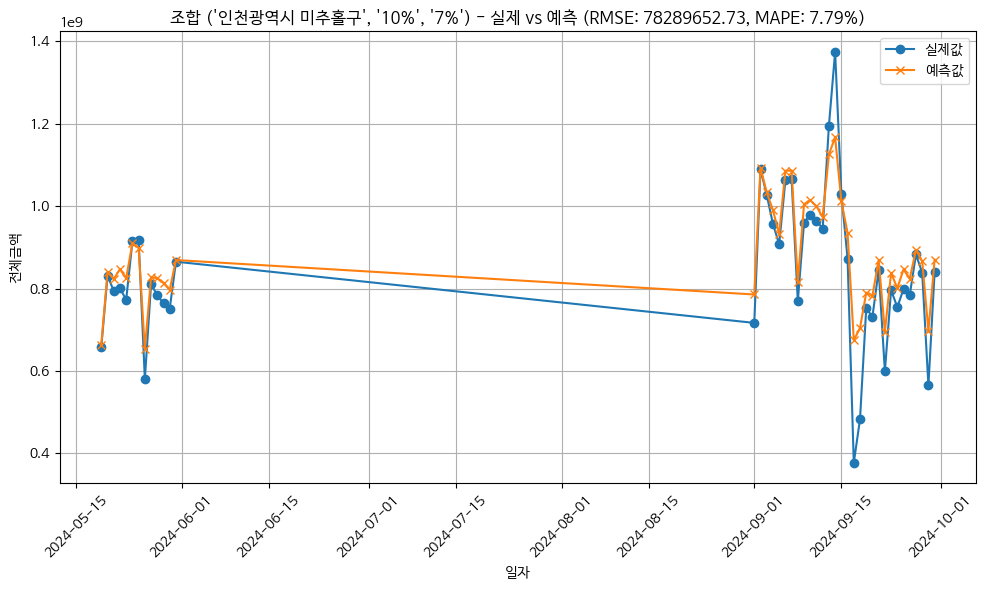

0:	learn: 428453111.4623501	test: 762144695.9388258	best: 762144695.9388258 (0)	total: 23.1ms	remaining: 23.1s
100:	learn: 76831656.2410958	test: 234964953.6002932	best: 234964953.6002932 (100)	total: 3.47s	remaining: 30.9s
200:	learn: 34239725.3834272	test: 192955341.7015084	best: 192915423.8480787 (199)	total: 6.58s	remaining: 26.2s
300:	learn: 23065864.4673559	test: 183084848.7386262	best: 183007436.6737069 (299)	total: 11.3s	remaining: 26.2s
400:	learn: 17367467.8142242	test: 176407410.7424062	best: 176407410.7424062 (400)	total: 16.1s	remaining: 24.1s
500:	learn: 14244176.1929282	test: 174371445.5195724	best: 174371445.5195724 (500)	total: 21.1s	remaining: 21s
600:	learn: 11590929.1434207	test: 173805624.7249845	best: 173805624.7249845 (600)	total: 25.6s	remaining: 17s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 173590926.3
bestIteration = 626

Shrink model to first 627 iterations.
[조합 ('인천광역시 부평구', '10%', '10%')] Validation RMSE: 173590932.20, MAPE: 5.66%


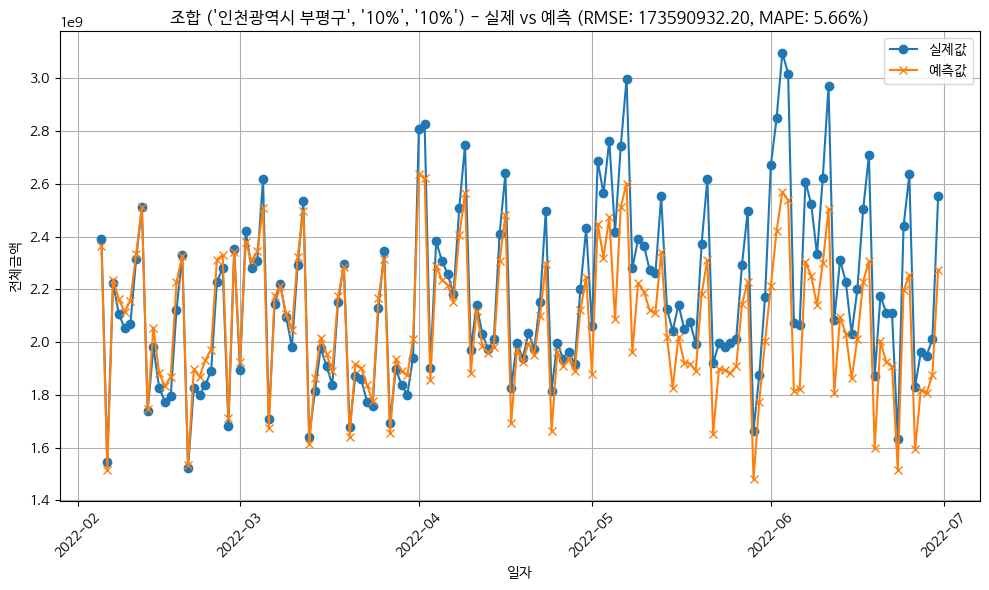

0:	learn: 406884823.7236621	test: 451471840.3220978	best: 451471840.3220978 (0)	total: 10.6ms	remaining: 10.6s
100:	learn: 113902070.3384496	test: 133613506.8140028	best: 133613506.8140028 (100)	total: 3.01s	remaining: 26.8s
200:	learn: 48420393.5424868	test: 70088701.0643955	best: 70088701.0643955 (200)	total: 6.48s	remaining: 25.7s
300:	learn: 23087092.9676949	test: 51434820.8425100	best: 51434820.8425100 (300)	total: 11.4s	remaining: 26.4s
400:	learn: 13753819.3251850	test: 44507051.8005476	best: 44507051.8005476 (400)	total: 14.7s	remaining: 21.9s
500:	learn: 9187635.4243003	test: 41660035.2351039	best: 41640709.7919152 (497)	total: 17.3s	remaining: 17.2s
600:	learn: 6572831.5895284	test: 40488425.6810278	best: 40488425.6810278 (600)	total: 20.1s	remaining: 13.4s
700:	learn: 4282779.4455884	test: 39058208.9152838	best: 39058208.9152838 (700)	total: 23.3s	remaining: 9.92s
800:	learn: 2965858.4420393	test: 38772217.8723209	best: 38772217.8723209 (800)	total: 25.6s	remaining: 6.37s
90

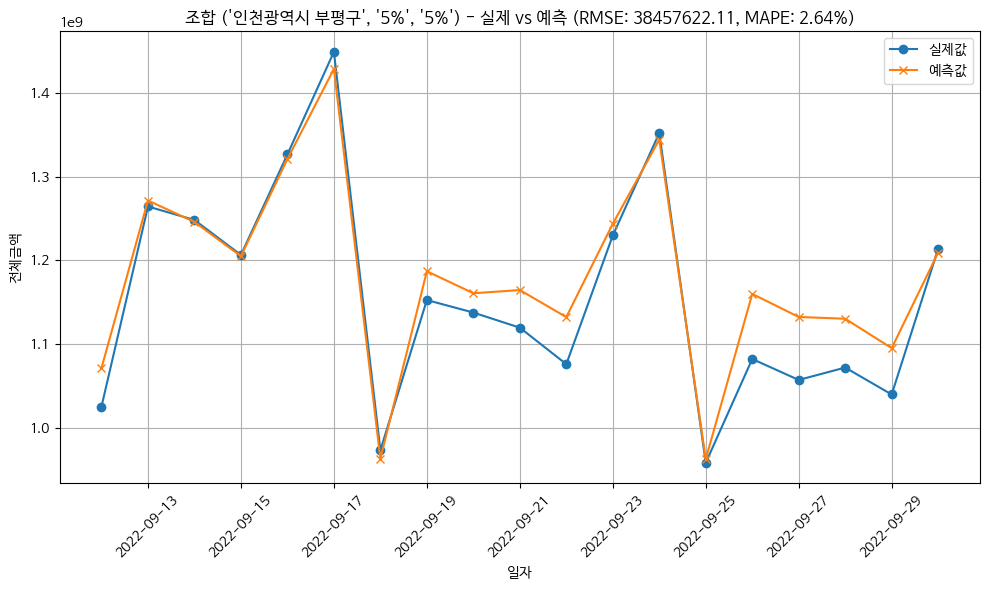

0:	learn: 221398216.2768904	test: 233136036.0174959	best: 233136036.0174959 (0)	total: 22ms	remaining: 21.9s
100:	learn: 49423127.3203055	test: 91684487.8321438	best: 91684487.8321438 (100)	total: 3.17s	remaining: 28.2s
200:	learn: 23059694.3303011	test: 72651416.6710474	best: 72651416.6710474 (200)	total: 6.51s	remaining: 25.9s
300:	learn: 14315614.1020175	test: 63995888.6593867	best: 63995888.6593867 (300)	total: 9.67s	remaining: 22.5s
400:	learn: 10439305.3299981	test: 61599770.1302627	best: 61593248.2472702 (397)	total: 12.9s	remaining: 19.2s
500:	learn: 7998251.7170773	test: 60561972.9704198	best: 60561972.9704198 (500)	total: 16.1s	remaining: 16s
600:	learn: 6339260.3501469	test: 59961341.6211440	best: 59961341.6211440 (600)	total: 19.1s	remaining: 12.7s
700:	learn: 5188664.0056983	test: 59678454.4797341	best: 59678454.4797341 (700)	total: 22s	remaining: 9.39s
800:	learn: 4480755.8368670	test: 59624784.3012970	best: 59599540.6128720 (751)	total: 25.2s	remaining: 6.25s
Stopped by 

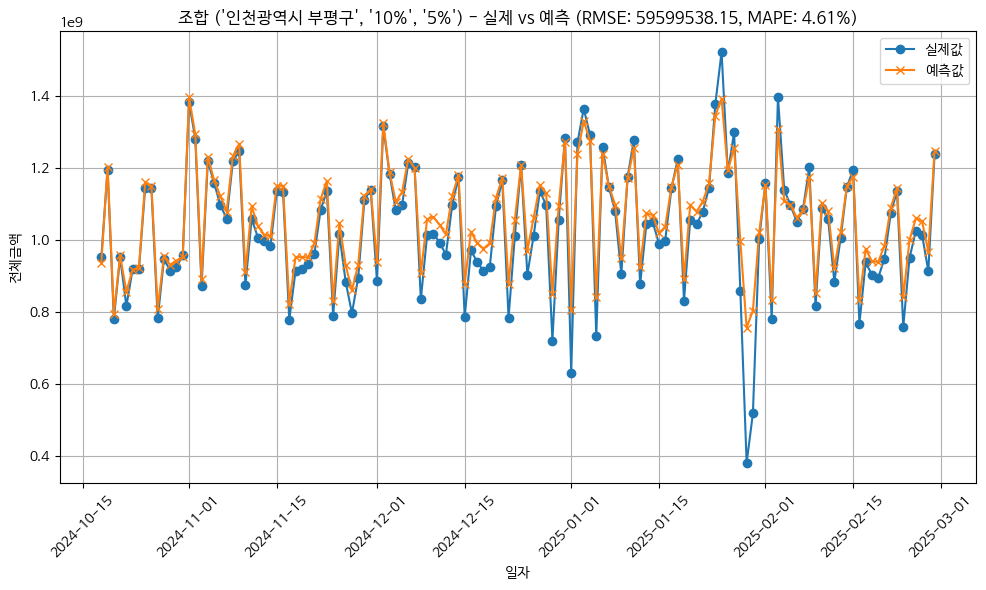

0:	learn: 353923776.6119061	test: 354651231.1703926	best: 354651231.1703926 (0)	total: 20.4ms	remaining: 20.4s
100:	learn: 101292406.9496161	test: 190810300.2245185	best: 190810300.2245185 (100)	total: 2.68s	remaining: 23.8s
200:	learn: 51669595.2368304	test: 153154516.7119565	best: 153154516.7119565 (200)	total: 5.41s	remaining: 21.5s
300:	learn: 28929893.3017712	test: 131670395.7200771	best: 131670395.7200771 (300)	total: 8.43s	remaining: 19.6s
400:	learn: 17409453.6041145	test: 121670075.9164287	best: 121670075.9164287 (400)	total: 11.4s	remaining: 17s
500:	learn: 11968545.1863939	test: 117480757.7992810	best: 117480757.7992810 (500)	total: 14.5s	remaining: 14.4s
600:	learn: 7575217.4037150	test: 115343236.2053028	best: 115343236.2053028 (600)	total: 17.6s	remaining: 11.7s
700:	learn: 5092180.8192519	test: 114445493.2150619	best: 114442739.9240044 (697)	total: 20.6s	remaining: 8.79s
800:	learn: 3598342.4668383	test: 113999776.1382356	best: 113999776.1382356 (800)	total: 23.7s	remain

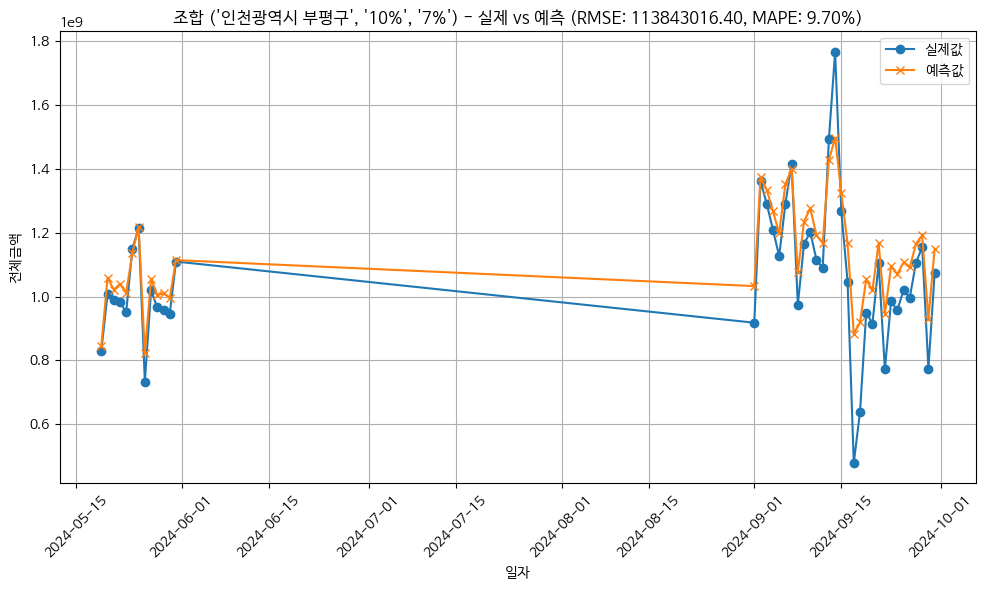

0:	learn: 498220090.2059998	test: 842186817.8817327	best: 842186817.8817327 (0)	total: 27ms	remaining: 27s
100:	learn: 98675677.2497887	test: 316752007.3607907	best: 316752007.3607907 (100)	total: 3.11s	remaining: 27.7s
200:	learn: 43338655.5248621	test: 261574649.8443299	best: 261574649.8443299 (200)	total: 6.34s	remaining: 25.2s
300:	learn: 28494755.1069882	test: 242253139.9278823	best: 242253139.9278823 (300)	total: 9.52s	remaining: 22.1s
400:	learn: 21829893.0350576	test: 238621320.9097312	best: 238618820.5454912 (365)	total: 12.4s	remaining: 18.5s
500:	learn: 16836760.6963112	test: 237322773.8628443	best: 237220087.7672689 (499)	total: 15.5s	remaining: 15.4s
600:	learn: 13536924.5098379	test: 236616631.3268272	best: 236574446.2800136 (597)	total: 18.5s	remaining: 12.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 236507050.4
bestIteration = 607

Shrink model to first 608 iterations.
[조합 ('인천광역시 서구', '10%', '10%')] Validation RMSE: 236507045.82, MAPE: 6.12%


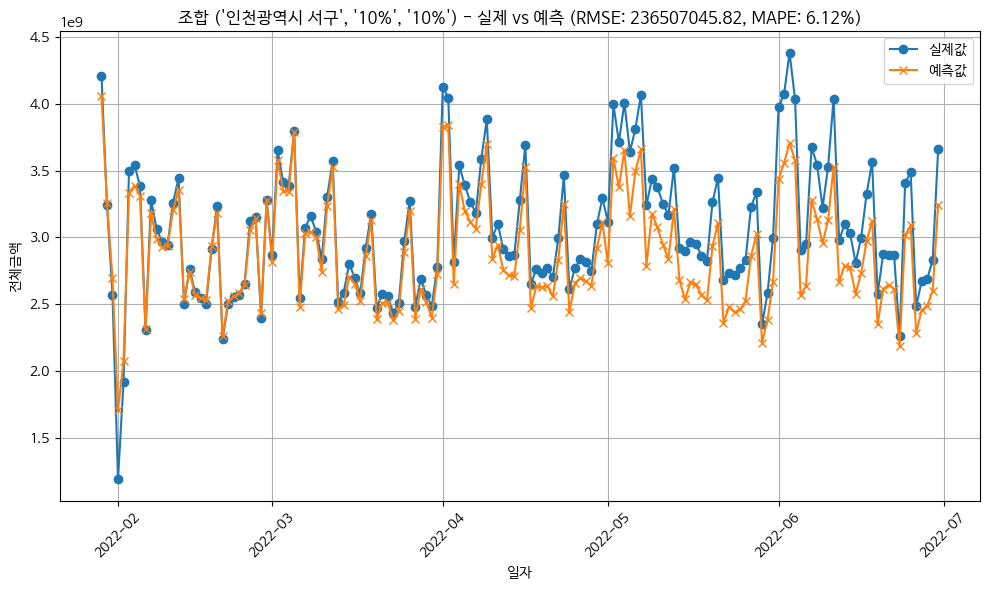

0:	learn: 533945209.3484247	test: 536822265.7436036	best: 536822265.7436036 (0)	total: 10.6ms	remaining: 10.5s
100:	learn: 165779621.5786071	test: 160959549.6823047	best: 160959549.6823047 (100)	total: 2.45s	remaining: 21.8s
200:	learn: 66322218.0081282	test: 96377260.8408816	best: 96377260.8408816 (200)	total: 5.2s	remaining: 20.7s
300:	learn: 25948109.1387090	test: 74328228.2073303	best: 74328228.2073303 (300)	total: 7.6s	remaining: 17.6s
400:	learn: 13375973.5803707	test: 67593658.9420858	best: 67534829.5153877 (398)	total: 10.1s	remaining: 15s
500:	learn: 8932086.4554982	test: 65249927.7692662	best: 65249927.7692662 (500)	total: 12.5s	remaining: 12.4s
600:	learn: 5850017.2121957	test: 64168250.7697551	best: 64168250.7697551 (600)	total: 14.8s	remaining: 9.84s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 63979687.92
bestIteration = 628

Shrink model to first 629 iterations.
[조합 ('인천광역시 서구', '5%', '5%')] Validation RMSE: 63979690.32, MAPE: 3.62%


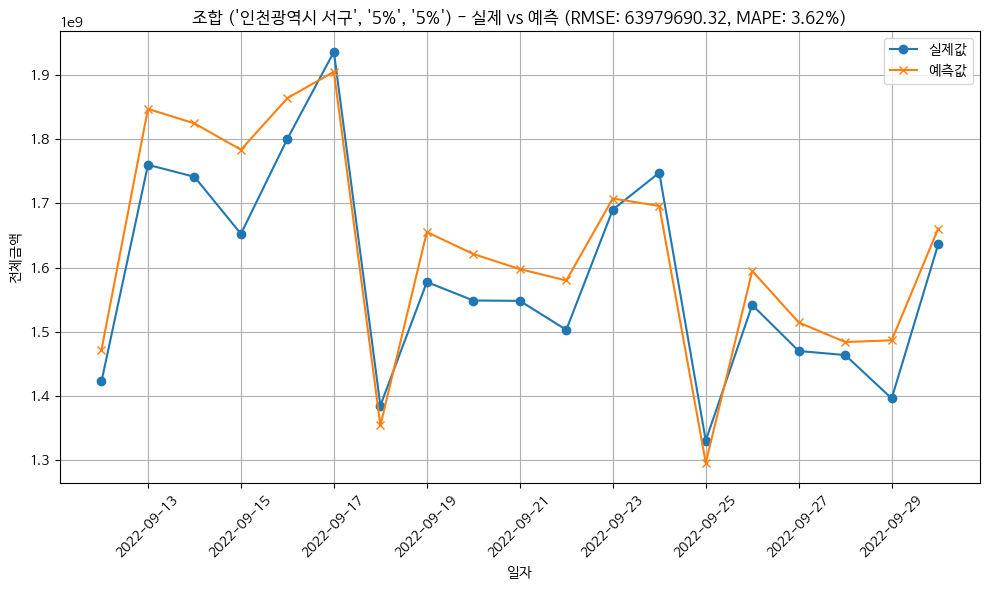

0:	learn: 305354381.3828321	test: 340755655.6890635	best: 340755655.6890635 (0)	total: 22.1ms	remaining: 22.1s
100:	learn: 70613249.9454102	test: 152867470.8848524	best: 152867470.8848524 (100)	total: 2.9s	remaining: 25.8s
200:	learn: 34473736.2193857	test: 123896585.9225262	best: 123896585.9225262 (200)	total: 5.71s	remaining: 22.7s
300:	learn: 21813702.3062791	test: 111714603.1661530	best: 111714603.1661530 (300)	total: 8.99s	remaining: 20.9s
400:	learn: 15418917.3069905	test: 106113087.5248538	best: 106113087.5248538 (400)	total: 12.4s	remaining: 18.5s
500:	learn: 11782995.2239353	test: 104297532.2012663	best: 104297532.2012663 (500)	total: 15.4s	remaining: 15.4s
600:	learn: 9676754.5008588	test: 103452484.5078231	best: 103398182.8166591 (598)	total: 18.3s	remaining: 12.1s
700:	learn: 7804297.2547092	test: 102612024.1942475	best: 102609562.6526204 (699)	total: 21.4s	remaining: 9.13s
800:	learn: 6389286.4004362	test: 102418274.3109984	best: 102401177.9885968 (789)	total: 26s	remainin

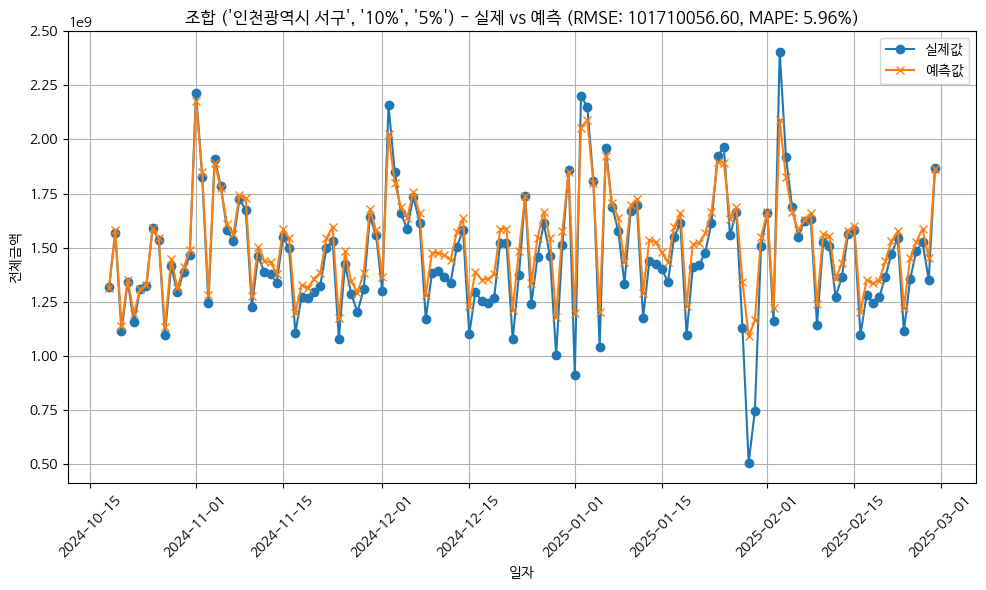

0:	learn: 576827328.8325921	test: 522685977.1708777	best: 522685977.1708777 (0)	total: 29.6ms	remaining: 29.6s
100:	learn: 167028360.1212460	test: 238791863.8061228	best: 238791863.8061228 (100)	total: 3.72s	remaining: 33.1s
200:	learn: 85652765.3329632	test: 188094449.2035414	best: 188094449.2035414 (200)	total: 7.21s	remaining: 28.7s
300:	learn: 48601910.8241709	test: 156805523.1070901	best: 156805523.1070901 (300)	total: 10.8s	remaining: 25.1s
400:	learn: 29363886.2977817	test: 139640227.0245097	best: 139640227.0245097 (400)	total: 14.1s	remaining: 21.1s
500:	learn: 19221060.1439820	test: 130794426.9088336	best: 130794426.9088336 (500)	total: 17.3s	remaining: 17.2s
600:	learn: 12976885.4059163	test: 126118015.1746047	best: 126118015.1746047 (600)	total: 20.1s	remaining: 13.3s
700:	learn: 9226264.8432851	test: 125257738.2060788	best: 125257738.2060788 (700)	total: 23.2s	remaining: 9.91s
800:	learn: 6858722.7458213	test: 124778648.5868912	best: 124759014.3357471 (796)	total: 26.7s	rem

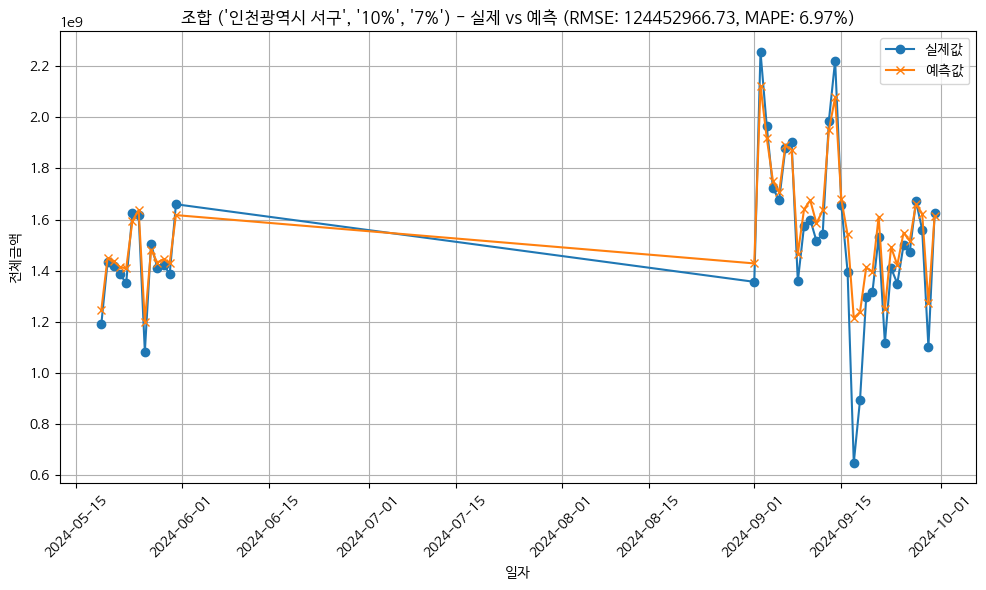

0:	learn: 454779516.7093456	test: 725437772.2931653	best: 725437772.2931653 (0)	total: 35ms	remaining: 35s
100:	learn: 83161369.4243881	test: 319279929.9414336	best: 319279929.9414336 (100)	total: 3.85s	remaining: 34.3s
200:	learn: 36606079.3223465	test: 267296041.4511436	best: 267296041.4511436 (200)	total: 7.86s	remaining: 31.3s
300:	learn: 24169944.3489383	test: 255426507.3116329	best: 254389707.3408349 (292)	total: 11.9s	remaining: 27.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 254389707.3
bestIteration = 292

Shrink model to first 293 iterations.
[조합 ('인천광역시 연수구', '10%', '10%')] Validation RMSE: 254389711.54, MAPE: 8.57%


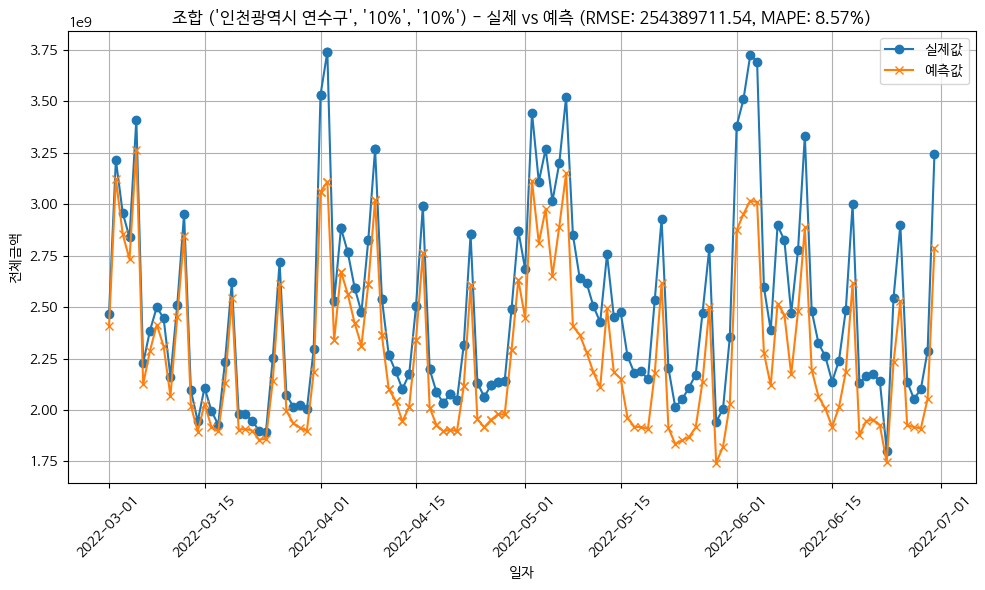

0:	learn: 413741554.2580286	test: 424943779.7487054	best: 424943779.7487054 (0)	total: 22.2ms	remaining: 22.1s
100:	learn: 119326644.6797992	test: 123026904.5429558	best: 122167623.9241133 (99)	total: 2.56s	remaining: 22.8s
200:	learn: 47889105.2494809	test: 70897317.2082858	best: 70897317.2082858 (200)	total: 5.59s	remaining: 22.2s
300:	learn: 19961189.9731781	test: 54432955.2525674	best: 54432955.2525674 (300)	total: 8.76s	remaining: 20.3s
400:	learn: 11034065.4279586	test: 50533686.0352799	best: 50521233.3107826 (399)	total: 11.7s	remaining: 17.4s
500:	learn: 6560770.3531783	test: 49444499.9120616	best: 49444499.9120616 (500)	total: 14.7s	remaining: 14.6s
600:	learn: 3665983.6921177	test: 48541441.4396731	best: 48541441.4396731 (600)	total: 17.8s	remaining: 11.8s
700:	learn: 2568552.5963733	test: 48378682.2256258	best: 48340562.8649416 (674)	total: 20.6s	remaining: 8.78s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 48340562.86
bestIteration = 674

Shrink model t

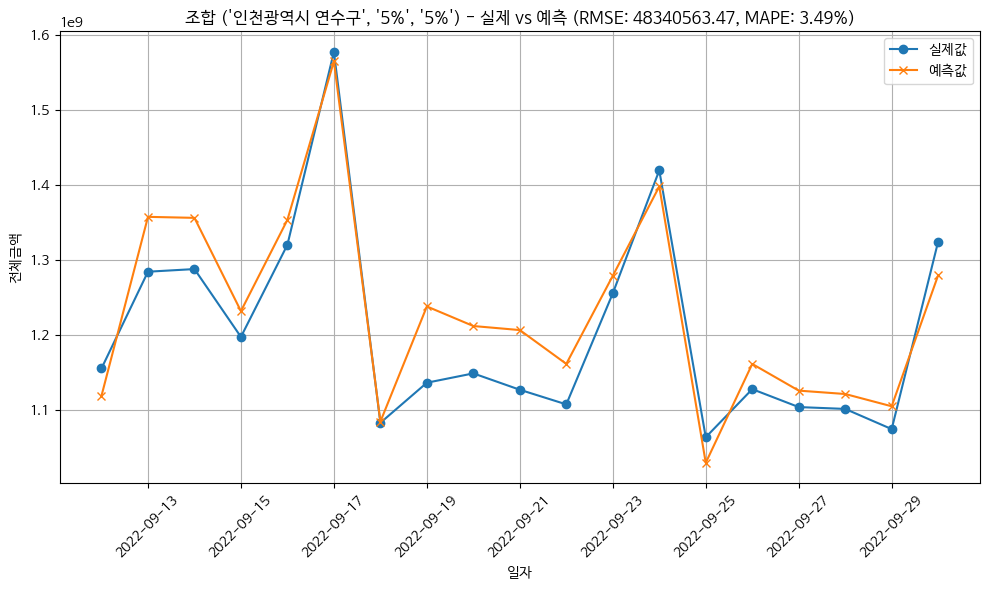

0:	learn: 249525604.3242308	test: 273461178.0892822	best: 273461178.0892822 (0)	total: 20.4ms	remaining: 20.4s
100:	learn: 50999063.0673796	test: 108562785.1548186	best: 108562785.1548186 (100)	total: 3.34s	remaining: 29.7s
200:	learn: 23671144.3732940	test: 85260329.7842899	best: 85260329.7842899 (200)	total: 7.18s	remaining: 28.5s
300:	learn: 15253838.6534325	test: 77295571.6936523	best: 77295571.6936523 (300)	total: 11.2s	remaining: 26s
400:	learn: 11027403.1630031	test: 74892545.7420579	best: 74892545.7420579 (400)	total: 15.3s	remaining: 22.8s
500:	learn: 8441637.8486165	test: 73770105.9730809	best: 73759851.4917126 (499)	total: 19.5s	remaining: 19.4s
600:	learn: 6636838.3248005	test: 73248946.4068150	best: 73248946.4068150 (600)	total: 23.8s	remaining: 15.8s
700:	learn: 5476229.8270236	test: 72571189.5622160	best: 72562339.7731662 (694)	total: 27.5s	remaining: 11.7s
800:	learn: 4495273.3026323	test: 72283870.0781088	best: 72266103.3099349 (779)	total: 31.1s	remaining: 7.73s
900:	

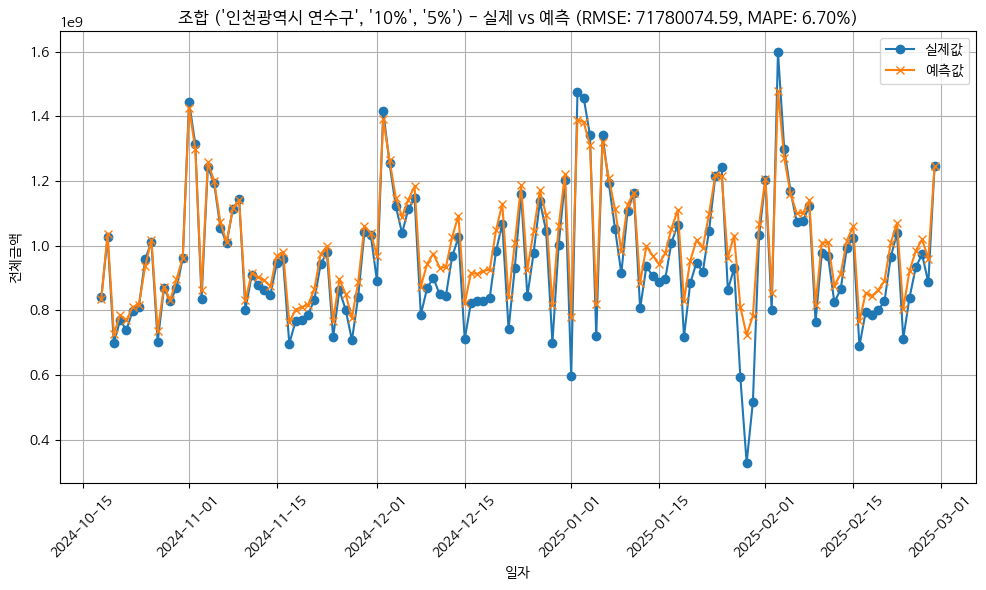

0:	learn: 487664889.7171299	test: 464902619.3225803	best: 464902619.3225803 (0)	total: 38.3ms	remaining: 38.2s
100:	learn: 126619169.4642678	test: 204508132.8670754	best: 204508132.8670754 (100)	total: 3.13s	remaining: 27.9s
200:	learn: 56049465.9732170	test: 154814450.1785637	best: 154814450.1785637 (200)	total: 6.44s	remaining: 25.6s
300:	learn: 30009236.9536581	test: 133891994.0546613	best: 133891994.0546613 (300)	total: 9.45s	remaining: 21.9s
400:	learn: 19165684.6804907	test: 125252796.4997928	best: 125188080.2405704 (397)	total: 12.5s	remaining: 18.7s
500:	learn: 12536065.6956804	test: 121692170.4486175	best: 121692170.4486175 (500)	total: 16s	remaining: 15.9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 121586753.5
bestIteration = 502

Shrink model to first 503 iterations.
[조합 ('인천광역시 연수구', '10%', '7%')] Validation RMSE: 121586754.92, MAPE: 12.47%


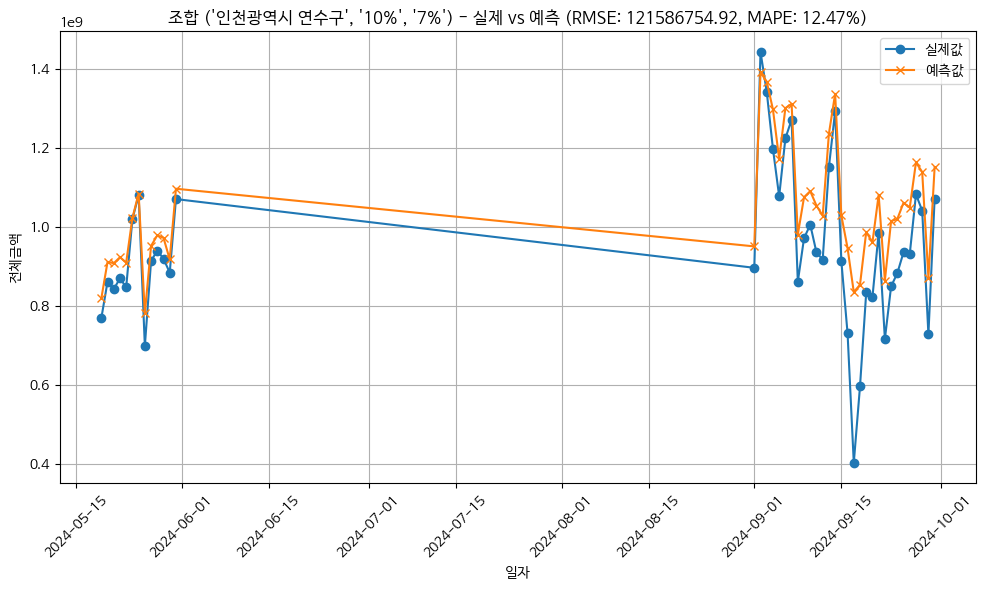

0:	learn: 8814231.3307592	test: 9146660.8608185	best: 9146660.8608185 (0)	total: 33ms	remaining: 33s
100:	learn: 1305344.2559386	test: 3264035.5954220	best: 3264035.5954220 (100)	total: 3.08s	remaining: 27.4s
200:	learn: 596567.2560086	test: 2565347.4990760	best: 2565347.4990760 (200)	total: 5.95s	remaining: 23.7s
300:	learn: 414459.8658165	test: 2393192.4802712	best: 2393192.4802712 (300)	total: 9.26s	remaining: 21.5s
400:	learn: 310524.4801944	test: 2308776.5749903	best: 2308120.4243373 (396)	total: 12.4s	remaining: 18.6s
500:	learn: 247334.7026201	test: 2290433.0935843	best: 2289969.1122484 (498)	total: 15.5s	remaining: 15.5s
600:	learn: 200956.1664538	test: 2266991.2385029	best: 2266991.2385029 (600)	total: 18.8s	remaining: 12.5s
700:	learn: 167609.4754545	test: 2250943.5366487	best: 2250943.5366487 (700)	total: 22.8s	remaining: 9.71s
800:	learn: 144391.6944158	test: 2236129.8660230	best: 2236129.8660230 (800)	total: 26s	remaining: 6.45s
900:	learn: 125209.8918552	test: 2223969.409

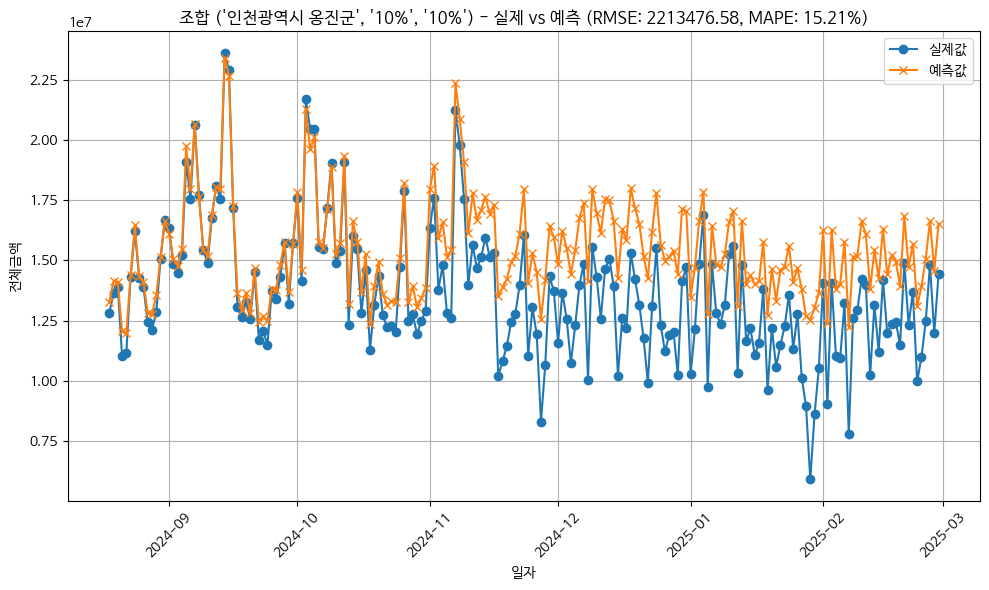

0:	learn: 4680086.5377038	test: 7413814.1789418	best: 7413814.1789418 (0)	total: 20.3ms	remaining: 20.3s
100:	learn: 1276750.9331743	test: 2840460.1749408	best: 2840460.1749408 (100)	total: 4.49s	remaining: 39.9s
200:	learn: 484721.7964093	test: 1462804.7601044	best: 1462804.7601044 (200)	total: 8.78s	remaining: 34.9s
300:	learn: 221005.5627699	test: 1069522.5671774	best: 1069522.5671774 (300)	total: 14s	remaining: 32.4s
400:	learn: 115963.7307161	test: 966894.1627062	best: 966894.1627062 (400)	total: 19s	remaining: 28.4s
500:	learn: 63531.0637120	test: 923719.5985017	best: 923455.2054733 (498)	total: 23.1s	remaining: 23s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 920664.6691
bestIteration = 519

Shrink model to first 520 iterations.
[조합 ('인천광역시 옹진군', '5%', '5%')] Validation RMSE: 920664.65, MAPE: 4.88%


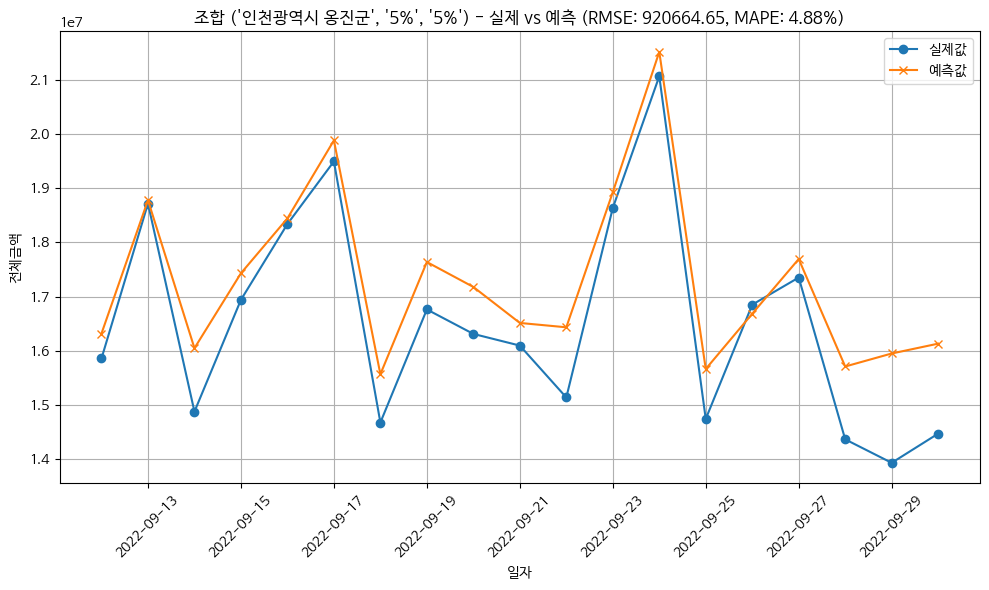

0:	learn: 3071084.2692231	test: 2120006.9581084	best: 2120006.9581084 (0)	total: 29.2ms	remaining: 29.2s
100:	learn: 777653.2481771	test: 1081132.1570036	best: 1064195.7563608 (96)	total: 3.87s	remaining: 34.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1064195.756
bestIteration = 96

Shrink model to first 97 iterations.
[조합 ('인천광역시 옹진군', '10%', '5%')] Validation RMSE: 1064195.74, MAPE: 5.12%


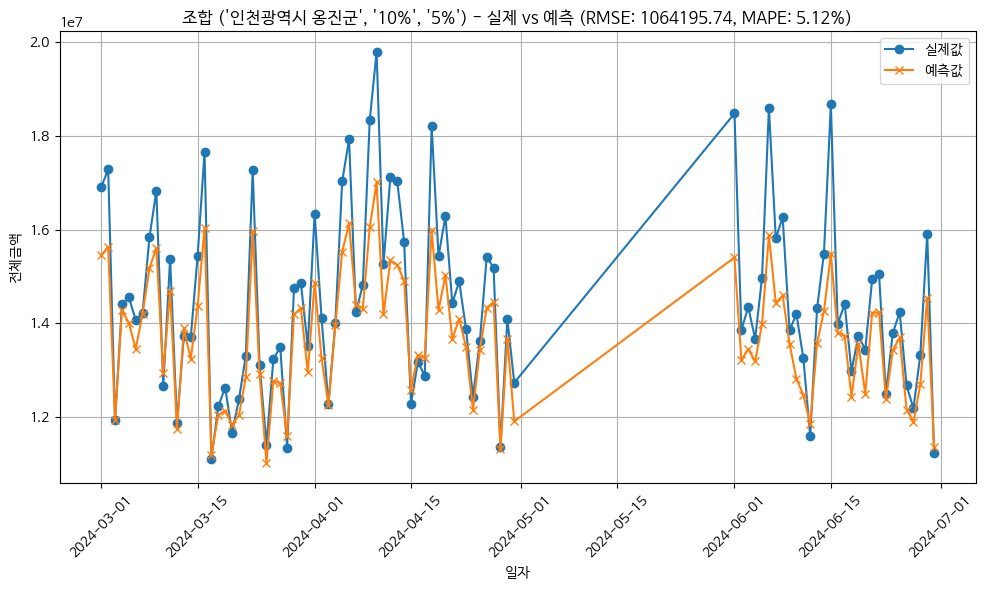

0:	learn: 4376647.0165165	test: 3010517.9334978	best: 3010517.9334978 (0)	total: 16.7ms	remaining: 16.6s
100:	learn: 1039402.4834498	test: 1485555.2137800	best: 1437677.0057438 (75)	total: 2.4s	remaining: 21.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1437677.006
bestIteration = 75

Shrink model to first 76 iterations.
[조합 ('인천광역시 옹진군', '10%', '7%')] Validation RMSE: 1437677.01, MAPE: 7.38%


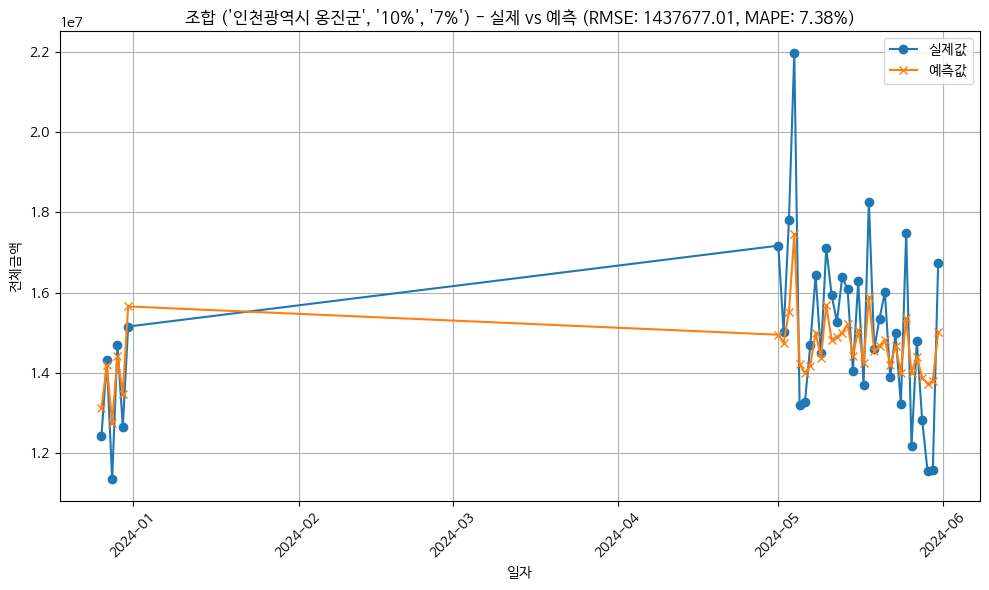

0:	learn: 171481211.5852214	test: 301286839.4643868	best: 301286839.4643868 (0)	total: 22.9ms	remaining: 22.9s
100:	learn: 30046056.6351225	test: 114597500.6718763	best: 114597500.6718763 (100)	total: 6.7s	remaining: 59.6s
200:	learn: 12443227.1193166	test: 97183713.0184920	best: 97183713.0184920 (200)	total: 10.8s	remaining: 42.8s
300:	learn: 7826899.8780652	test: 93820576.4761503	best: 93820576.4761503 (300)	total: 14.7s	remaining: 34.1s
400:	learn: 5679431.1221400	test: 93407858.0540045	best: 93369303.8655311 (396)	total: 18.2s	remaining: 27.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 93365195.91
bestIteration = 401

Shrink model to first 402 iterations.
[조합 ('인천광역시 중구', '10%', '10%')] Validation RMSE: 93365193.41, MAPE: 7.77%


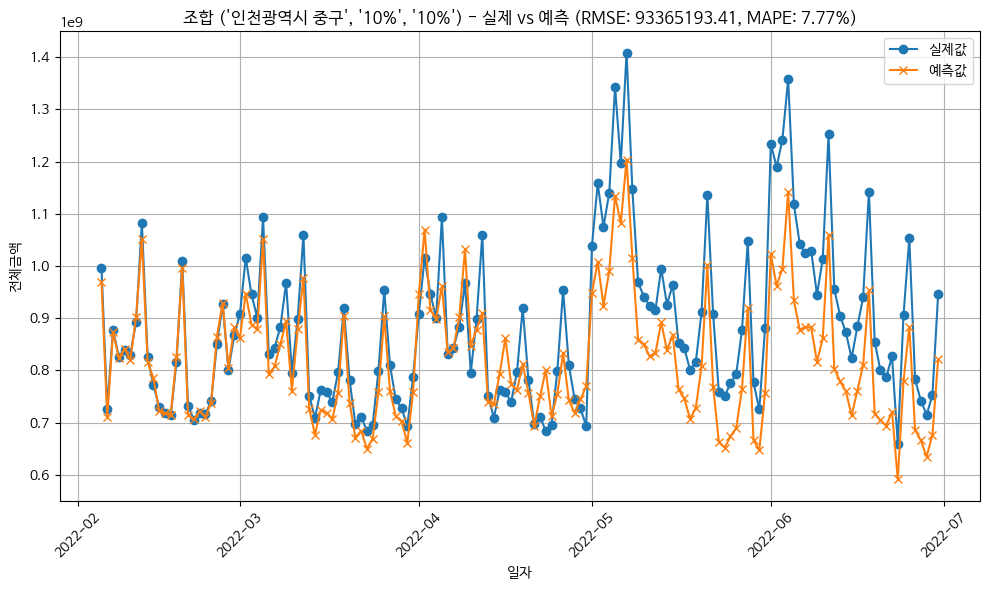

0:	learn: 140946797.7856399	test: 159320959.4721513	best: 159320959.4721513 (0)	total: 23.7ms	remaining: 23.7s
100:	learn: 37503861.7443085	test: 94889199.6670003	best: 94889199.6670003 (100)	total: 2.55s	remaining: 22.7s
200:	learn: 14598333.2445278	test: 76608688.4135420	best: 76608688.4135420 (200)	total: 5.61s	remaining: 22.3s
300:	learn: 6236609.6527985	test: 63963977.3730547	best: 63963977.3730547 (300)	total: 8.6s	remaining: 20s
400:	learn: 3203771.7366593	test: 59307127.3369747	best: 59307127.3369747 (400)	total: 11.3s	remaining: 16.9s
500:	learn: 1830731.7125769	test: 58298938.6731085	best: 58298938.6731085 (500)	total: 14.1s	remaining: 14.1s
600:	learn: 1276208.7379654	test: 58069019.6683320	best: 58069019.6683320 (600)	total: 17.3s	remaining: 11.5s
700:	learn: 901459.3272810	test: 57981559.0427889	best: 57959827.0618959 (652)	total: 20.3s	remaining: 8.67s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 57959827.06
bestIteration = 652

Shrink model to first 

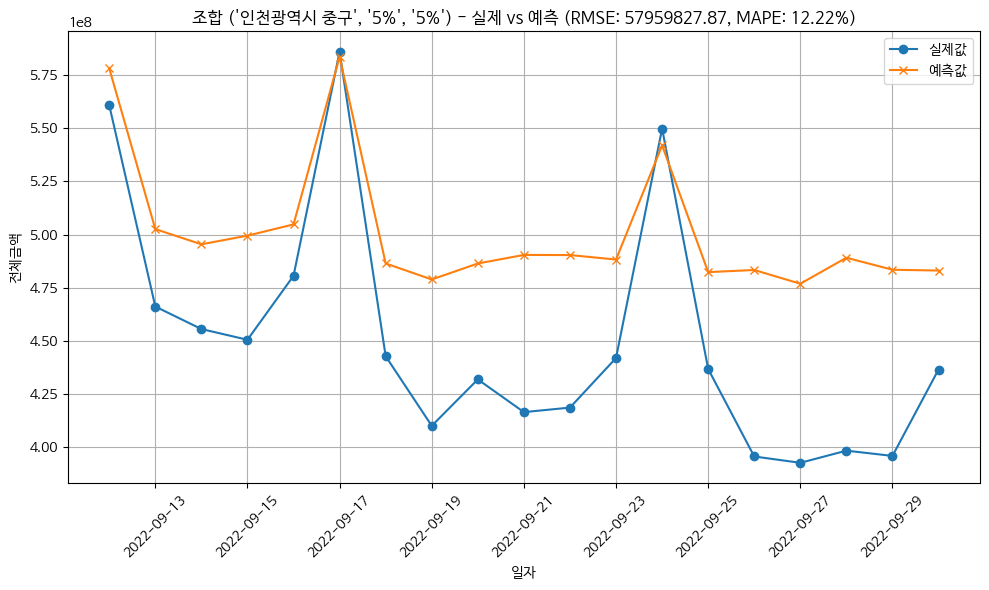

0:	learn: 85629433.3582277	test: 91924380.1849144	best: 91924380.1849144 (0)	total: 20.2ms	remaining: 20.2s
100:	learn: 17482614.3297256	test: 35911282.0304828	best: 35911282.0304828 (100)	total: 3.11s	remaining: 27.7s
200:	learn: 7977002.3446763	test: 29958243.6184495	best: 29958243.6184495 (200)	total: 5.97s	remaining: 23.7s
300:	learn: 5069596.5637733	test: 28509153.6840642	best: 28506696.5715100 (299)	total: 10.1s	remaining: 23.5s
400:	learn: 3613647.1601265	test: 27953768.3276009	best: 27938484.0230184 (397)	total: 14.9s	remaining: 22.3s
500:	learn: 2850803.3849631	test: 27538178.2419970	best: 27538178.2419970 (500)	total: 18.7s	remaining: 18.6s
600:	learn: 2299430.8183035	test: 27214407.3705377	best: 27210606.6468330 (598)	total: 22.7s	remaining: 15.1s
700:	learn: 1898316.5709057	test: 26989243.2976681	best: 26989243.2976681 (700)	total: 26.9s	remaining: 11.5s
800:	learn: 1591513.3001930	test: 26752160.2974037	best: 26751773.4749992 (799)	total: 31.6s	remaining: 7.85s
900:	learn:

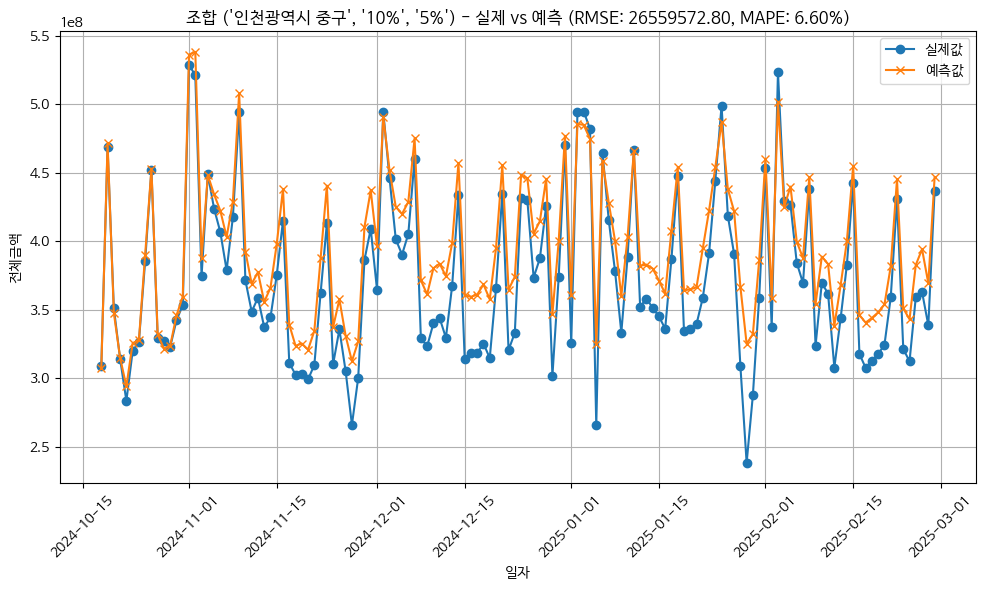

0:	learn: 142473251.7817298	test: 136680561.0596823	best: 136680561.0596823 (0)	total: 18.8ms	remaining: 18.8s
100:	learn: 32855868.3206929	test: 52866489.0193827	best: 52866489.0193827 (100)	total: 4.67s	remaining: 41.6s
200:	learn: 16683904.9613355	test: 40818179.5313432	best: 40818179.5313432 (200)	total: 7.66s	remaining: 30.4s
300:	learn: 9997170.5893470	test: 33052492.6816854	best: 33052492.6816854 (300)	total: 12.6s	remaining: 29.4s
400:	learn: 6253497.1483002	test: 29174955.1266360	best: 29174955.1266360 (400)	total: 15.6s	remaining: 23.3s
500:	learn: 4125711.4284710	test: 28109732.5138837	best: 28109732.5138837 (500)	total: 19.2s	remaining: 19.2s
600:	learn: 2704831.7717352	test: 27303671.7176459	best: 27303671.7176459 (600)	total: 24s	remaining: 15.9s
700:	learn: 1906237.4978569	test: 26828711.6205949	best: 26828711.6205949 (700)	total: 28.7s	remaining: 12.2s
800:	learn: 1425945.9985671	test: 26620591.2350316	best: 26620591.2350316 (800)	total: 33s	remaining: 8.19s
900:	learn:

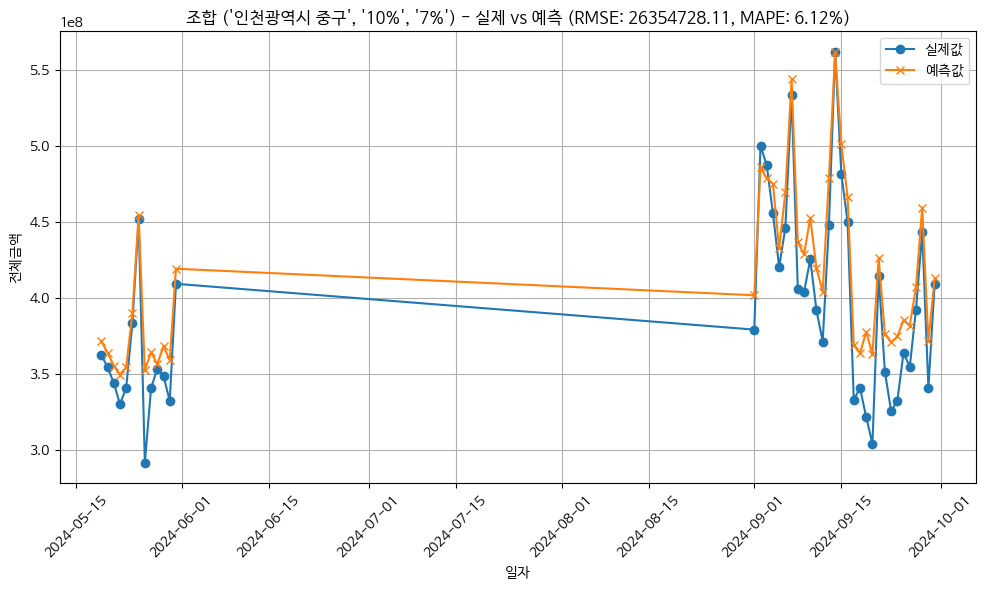

In [5]:

import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import matplotlib
import seaborn as sns

# 한글 폰트 설정
font_location = 'C:\\Windows\\Fonts\\Hancom Gothic Regular.ttf'
font_name = fm.FontProperties(fname=font_location).get_name()
matplotlib.rc('font', family=font_name)

# 조합별 데이터프레임 생성 (이전 코드 재사용)
value_columns = ['지역', '연매출 3억원 이하', '연매출 3억~30억원']
df['value_combination'] = df[value_columns].apply(tuple, axis=1)
combinations = df['value_combination'].unique()
combination_dfs = {}
for combo in combinations:
    df_combo = df[df['value_combination'] == combo].copy()
    combination_dfs[combo] = df_combo
df = df.drop(columns='value_combination')


# 조합별 모델링
for combo, data in combination_dfs.items():
    # 데이터 준비
    data['일자'] = pd.to_datetime(data['일자'])


    # 타겟 설정
    target = '전체금액'
    features = [col for col in data.columns if col not in [target, 'value_combination','lpf_trend']]
    
    # 범주형 피처 선택 (value_combination 제외)
    categorical_features = [col for col in data.select_dtypes(include='object').columns if col in features]

    if len(data) < 10:
        print(f"스킵: 조합 {combo} (데이터 부족)")
        continue

    X = data[features]
    y = data[target]

    if y.nunique() <= 1:
        print(f"스킵: 조합 {combo} (타겟값 모두 동일)")
        continue

    # 데이터 분할
    split_idx = int(len(data) * 0.8)
    X_train = X.iloc[:split_idx]
    X_valid = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_valid = y.iloc[split_idx:]

    # Pool 생성
    train_pool = Pool(X_train, y_train, cat_features=categorical_features)
    valid_pool = Pool(X_valid, y_valid, cat_features=categorical_features)

    # 모델 학습
    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.03,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        early_stopping_rounds=50,
        verbose=100
    )

    model.fit(train_pool, eval_set=valid_pool)

    # 예측
    y_pred = model.predict(X_valid)

    # 일자 기준 정렬
    X_valid = X_valid.copy()
    X_valid['일자'] = data['일자'].iloc[split_idx:]
    sorted_idx = X_valid['일자'].argsort()
    X_valid = X_valid.iloc[sorted_idx]
    y_valid = y_valid.iloc[sorted_idx]
    y_pred = y_pred[sorted_idx]

    # RMSE 계산
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

    # MAPE 계산
    mape = np.mean(np.abs((y_valid - y_pred) / y_valid)) * 100

    print(f"[조합 {combo}] Validation RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

    # 시각화
    plt.figure(figsize=(10, 6))
    plt.plot(X_valid['일자'], y_valid.values, label='실제값', marker='o')
    plt.plot(X_valid['일자'], y_pred, label='예측값', marker='x')
    plt.title(f"조합 {combo} - 실제 vs 예측 (RMSE: {rmse:.2f}, MAPE: {mape:.2f}%)")
    plt.xlabel("일자")
    plt.ylabel("전체금액")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

0:	learn: 138157467.4479834	test: 59731128.1121955	best: 59731128.1121955 (0)	total: 36.6ms	remaining: 36.6s
100:	learn: 17442451.2631184	test: 14868464.5728591	best: 14868464.5728591 (100)	total: 3.44s	remaining: 30.6s
200:	learn: 7706172.6744146	test: 9429575.1620367	best: 9429575.1620367 (200)	total: 6.61s	remaining: 26.3s
300:	learn: 5570819.7663843	test: 8414600.7878010	best: 8414600.7878010 (300)	total: 9.71s	remaining: 22.6s
400:	learn: 4295108.2987690	test: 7601910.3805848	best: 7601910.3805848 (400)	total: 12.9s	remaining: 19.3s
500:	learn: 3442868.1038011	test: 6858339.6894607	best: 6858339.6894607 (500)	total: 16.1s	remaining: 16s
600:	learn: 2838151.6476435	test: 6158098.7378008	best: 6158035.1015975 (599)	total: 19.3s	remaining: 12.8s
700:	learn: 2428499.3320280	test: 5812957.0573470	best: 5810122.6569513 (699)	total: 22.6s	remaining: 9.66s
800:	learn: 2094129.1300016	test: 5544917.7190714	best: 5543681.7671562 (799)	total: 25.9s	remaining: 6.43s
900:	learn: 1839641.147165

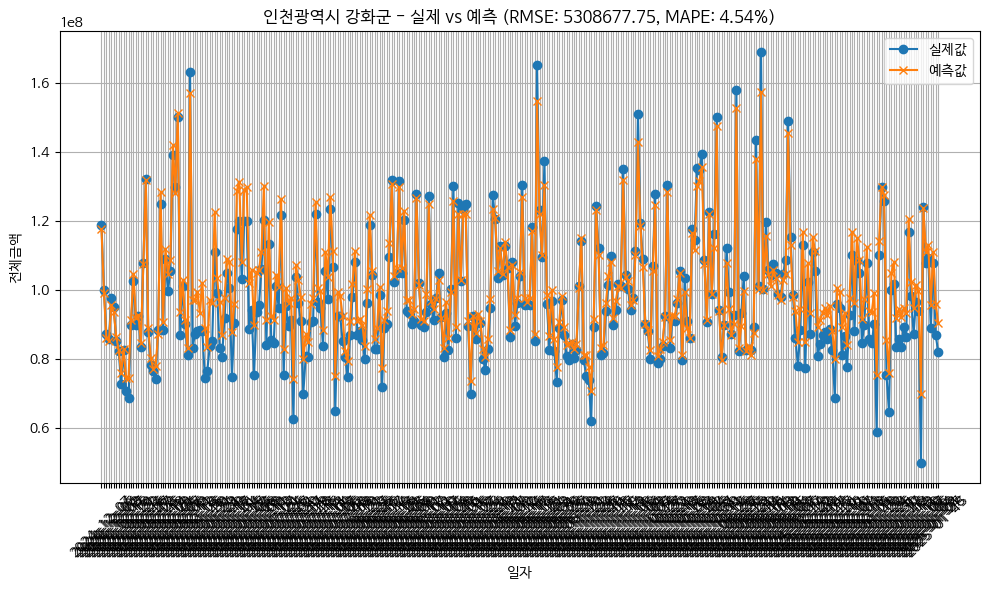

0:	learn: 245099130.3748773	test: 253476140.1872705	best: 253476140.1872705 (0)	total: 22.1ms	remaining: 22.1s
100:	learn: 41465993.5066066	test: 48655131.3343276	best: 48655131.3343276 (100)	total: 3.31s	remaining: 29.5s
200:	learn: 19251286.4130513	test: 26542390.4275293	best: 26542390.4275293 (200)	total: 6.93s	remaining: 27.6s
300:	learn: 13473678.6071270	test: 21649638.6883878	best: 21649638.6883878 (300)	total: 11s	remaining: 25.6s
400:	learn: 10501931.5538115	test: 19539321.0042807	best: 19539321.0042807 (400)	total: 15.1s	remaining: 22.6s
500:	learn: 8623085.7596236	test: 18555391.3240869	best: 18555391.3240869 (500)	total: 19.1s	remaining: 19s
600:	learn: 7321857.1113471	test: 18095153.2260303	best: 18095153.2260303 (600)	total: 22.7s	remaining: 15.1s
700:	learn: 6364783.6423528	test: 17641121.7032141	best: 17641121.7032141 (700)	total: 26.1s	remaining: 11.1s
800:	learn: 5638017.7273988	test: 17439982.9671716	best: 17439982.9671716 (800)	total: 29.5s	remaining: 7.32s
900:	lear

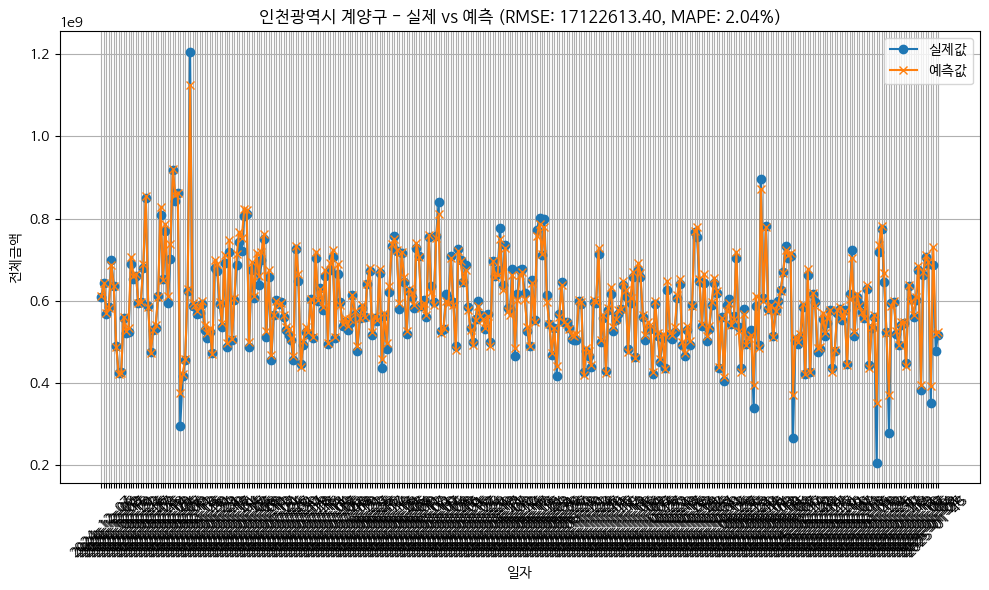

0:	learn: 596860503.5493821	test: 652784907.2232877	best: 652784907.2232877 (0)	total: 20.4ms	remaining: 20.4s
100:	learn: 88382956.8206478	test: 118668099.5934321	best: 118668099.5934321 (100)	total: 3.29s	remaining: 29.3s
200:	learn: 38686330.4403496	test: 59431403.9016581	best: 59431403.9016581 (200)	total: 7.28s	remaining: 29s
300:	learn: 27322621.3681446	test: 47925945.5456360	best: 47925945.5456360 (300)	total: 11.2s	remaining: 26s
400:	learn: 21605216.7590236	test: 42948197.7989598	best: 42948197.7989598 (400)	total: 14.4s	remaining: 21.6s
500:	learn: 18205918.7249111	test: 40853498.7250919	best: 40853498.7250919 (500)	total: 17.7s	remaining: 17.6s
600:	learn: 15614353.5098049	test: 39587027.6912269	best: 39587027.6912269 (600)	total: 21.2s	remaining: 14s
700:	learn: 13781396.2302941	test: 38596247.5191796	best: 38590570.7226641 (699)	total: 24.7s	remaining: 10.5s
800:	learn: 12410138.7285002	test: 37978510.7792135	best: 37970398.4228192 (796)	total: 28s	remaining: 6.94s
900:	le

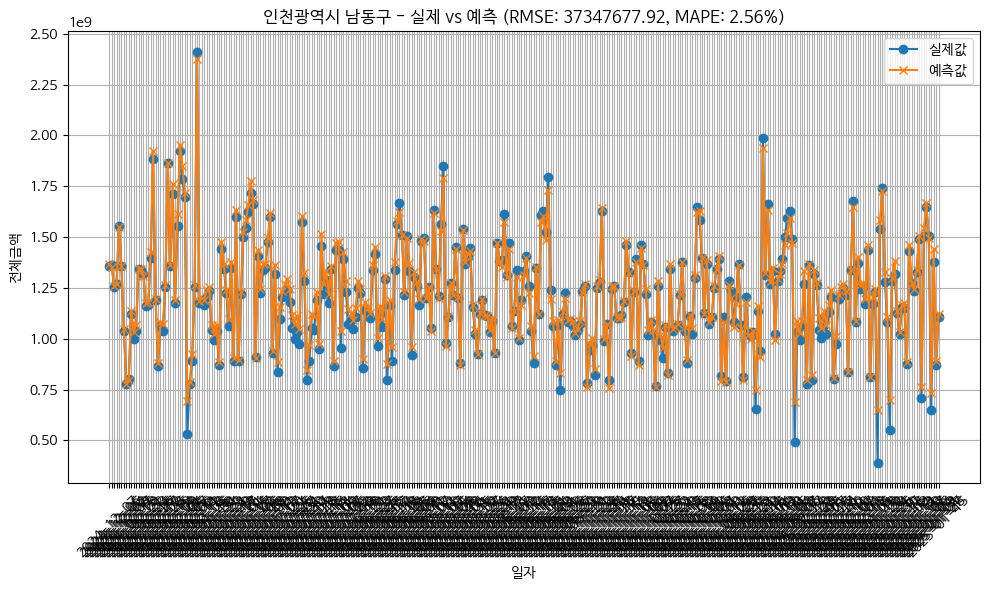

0:	learn: 50562137.7269456	test: 51035158.1472361	best: 51035158.1472361 (0)	total: 33.6ms	remaining: 33.5s
100:	learn: 7904139.2731839	test: 10214019.5064969	best: 10214019.5064969 (100)	total: 3.41s	remaining: 30.4s
200:	learn: 3760607.2271437	test: 5712202.8400957	best: 5712202.8400957 (200)	total: 6.64s	remaining: 26.4s
300:	learn: 2707477.7630351	test: 4717322.0113127	best: 4717322.0113127 (300)	total: 9.95s	remaining: 23.1s
400:	learn: 2100748.0745899	test: 4253151.5946414	best: 4253151.5946414 (400)	total: 13.6s	remaining: 20.4s
500:	learn: 1716333.9805140	test: 4066573.0698464	best: 4064711.7338350 (498)	total: 19.4s	remaining: 19.3s
600:	learn: 1448256.3616474	test: 3931979.4166599	best: 3931979.4166599 (600)	total: 23.6s	remaining: 15.7s
700:	learn: 1246868.4376205	test: 3851275.4851121	best: 3851229.1832673 (699)	total: 27s	remaining: 11.5s
800:	learn: 1102387.6922027	test: 3773396.3436607	best: 3772943.2687018 (797)	total: 30.5s	remaining: 7.58s
900:	learn: 988470.8598176	t

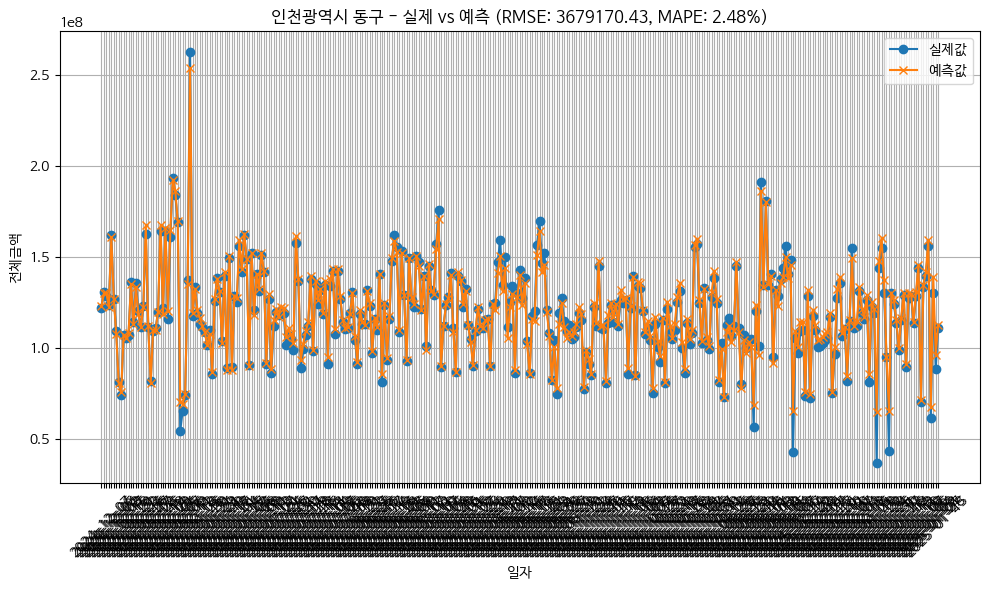

0:	learn: 340201844.8862055	test: 321966840.4700317	best: 321966840.4700317 (0)	total: 24ms	remaining: 23.9s
100:	learn: 52488299.8217503	test: 59475224.6613347	best: 59475224.6613347 (100)	total: 3.98s	remaining: 35.4s
200:	learn: 23636600.0587008	test: 31820638.4161462	best: 31820638.4161462 (200)	total: 8.08s	remaining: 32.1s
300:	learn: 17115926.8231427	test: 26107273.4848324	best: 26107273.4848324 (300)	total: 12.1s	remaining: 28.2s
400:	learn: 13622353.3207263	test: 23635416.4687340	best: 23635416.4687340 (400)	total: 16s	remaining: 23.9s
500:	learn: 11353153.9488590	test: 22519545.6017632	best: 22519545.6017632 (500)	total: 19.8s	remaining: 19.7s
600:	learn: 9725798.8422718	test: 21894026.1600860	best: 21889795.3309539 (597)	total: 23.3s	remaining: 15.5s
700:	learn: 8535240.0042713	test: 21354516.6807857	best: 21354516.6807857 (700)	total: 28.2s	remaining: 12s
800:	learn: 7542090.1665417	test: 21013038.7406975	best: 21009662.5506977 (798)	total: 32.1s	remaining: 7.98s
900:	learn

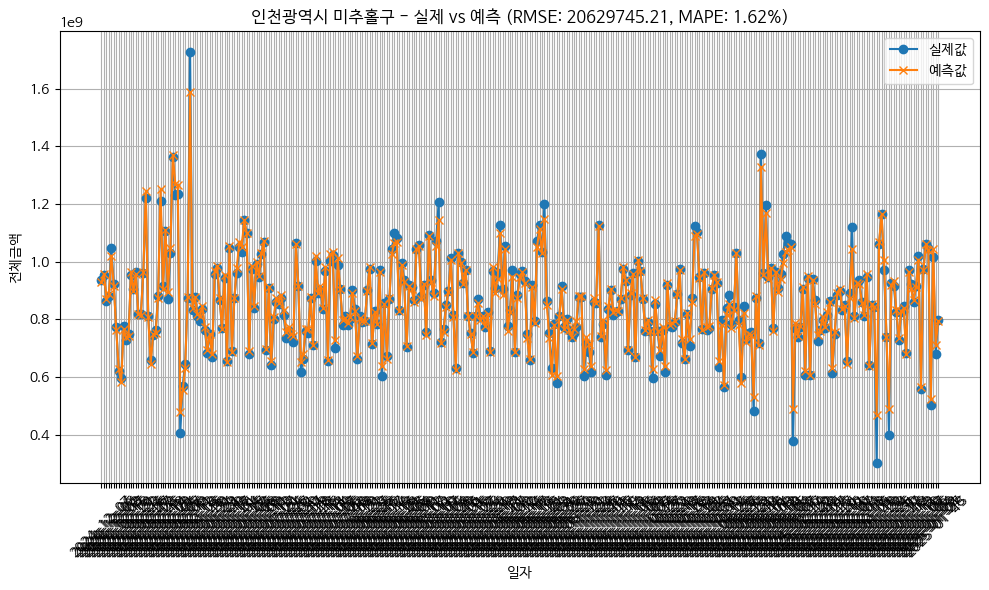

0:	learn: 445890853.7156336	test: 422378618.9599078	best: 422378618.9599078 (0)	total: 20.7ms	remaining: 20.7s
100:	learn: 67521822.4618717	test: 83139603.2827406	best: 83139603.2827406 (100)	total: 3.37s	remaining: 30s
200:	learn: 30031414.1380768	test: 43523467.2139708	best: 43523467.2139708 (200)	total: 6.81s	remaining: 27.1s
300:	learn: 22202807.2075266	test: 35862845.4753870	best: 35862845.4753870 (300)	total: 10.4s	remaining: 24.2s
400:	learn: 17658809.5416577	test: 32028803.5799376	best: 32028803.5799376 (400)	total: 13.8s	remaining: 20.6s
500:	learn: 14380172.0620112	test: 30414035.9156968	best: 30414035.9156968 (500)	total: 17s	remaining: 17s
600:	learn: 11977379.1522953	test: 29267953.6977987	best: 29267953.6977987 (600)	total: 20.2s	remaining: 13.4s
700:	learn: 10236888.6048946	test: 28543284.8438867	best: 28543284.8438867 (700)	total: 23.5s	remaining: 10s
800:	learn: 8990263.7120629	test: 28118661.5512813	best: 28118661.5512813 (800)	total: 26.7s	remaining: 6.64s
900:	learn

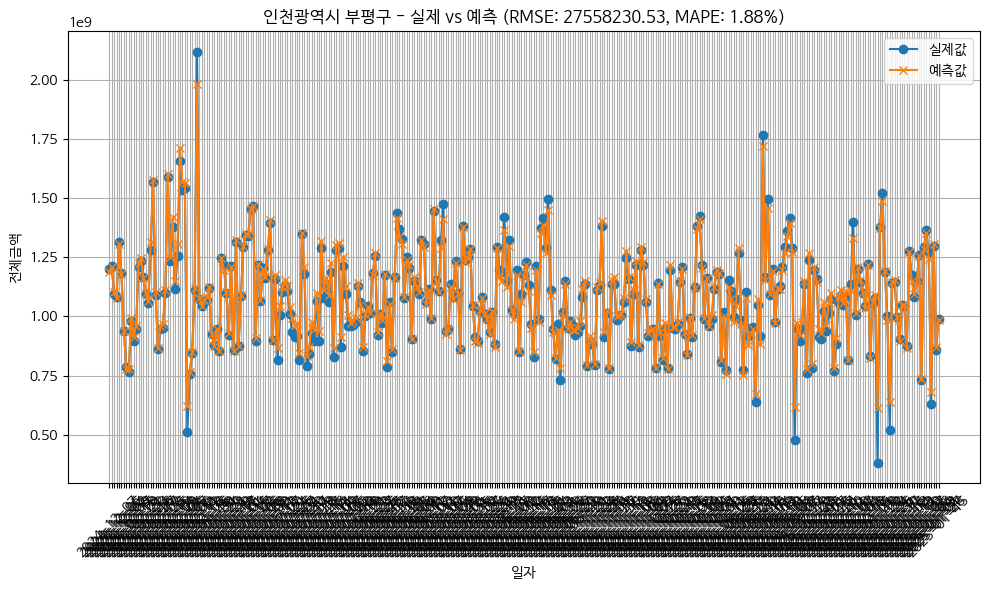

0:	learn: 615863729.0030764	test: 692434525.3691218	best: 692434525.3691218 (0)	total: 28.6ms	remaining: 28.6s
100:	learn: 100963476.7962302	test: 133588413.3651125	best: 133588413.3651125 (100)	total: 3.52s	remaining: 31.3s
200:	learn: 46495405.5405215	test: 73646346.0554265	best: 73646346.0554265 (200)	total: 6.85s	remaining: 27.2s
300:	learn: 31205774.6713629	test: 59227321.0685417	best: 59227321.0685417 (300)	total: 10.3s	remaining: 23.9s
400:	learn: 24045194.4423837	test: 53306127.6414281	best: 53306127.6414281 (400)	total: 13.6s	remaining: 20.3s
500:	learn: 19824025.6159761	test: 51032627.9854658	best: 51032627.9854658 (500)	total: 17s	remaining: 16.9s
600:	learn: 17026182.8578570	test: 49672596.1768988	best: 49672596.1768988 (600)	total: 20.8s	remaining: 13.8s
700:	learn: 14873321.9445236	test: 48991652.7573640	best: 48991652.7573640 (700)	total: 24.6s	remaining: 10.5s
800:	learn: 13340382.0943955	test: 48671870.8468258	best: 48668629.7858700 (784)	total: 28.4s	remaining: 7.05s


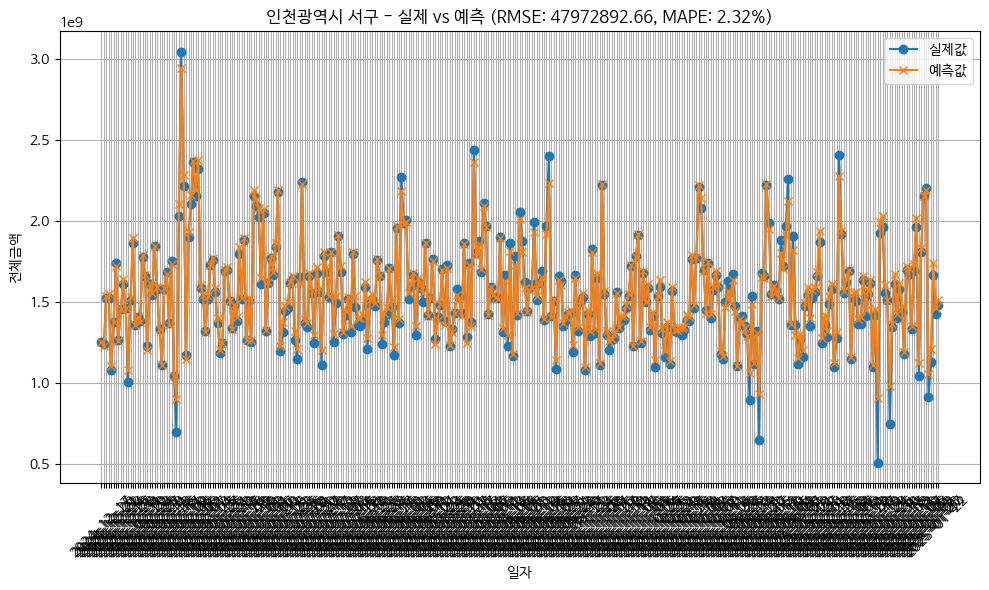

0:	learn: 578466070.2788651	test: 716609912.9951936	best: 716609912.9951936 (0)	total: 33ms	remaining: 33s
100:	learn: 84829609.4048753	test: 125832971.5819241	best: 125832971.5819241 (100)	total: 4.09s	remaining: 36.4s
200:	learn: 37098497.2676900	test: 64715282.2707200	best: 64715282.2707200 (200)	total: 7.76s	remaining: 30.9s
300:	learn: 25955249.0283721	test: 52291711.1427352	best: 52291711.1427352 (300)	total: 11.4s	remaining: 26.5s
400:	learn: 20569733.3585792	test: 46656909.1996855	best: 46656909.1996855 (400)	total: 15s	remaining: 22.4s
500:	learn: 17066863.1854206	test: 44564094.3728987	best: 44564094.3728987 (500)	total: 18.3s	remaining: 18.2s
600:	learn: 14822631.0880434	test: 43446288.4118133	best: 43446288.4118133 (600)	total: 21.6s	remaining: 14.4s
700:	learn: 13050453.6422756	test: 42987481.8906323	best: 42987481.8906323 (700)	total: 25.6s	remaining: 10.9s
800:	learn: 11644209.6243863	test: 42403462.9930949	best: 42403462.9930949 (800)	total: 29.5s	remaining: 7.33s
900:	

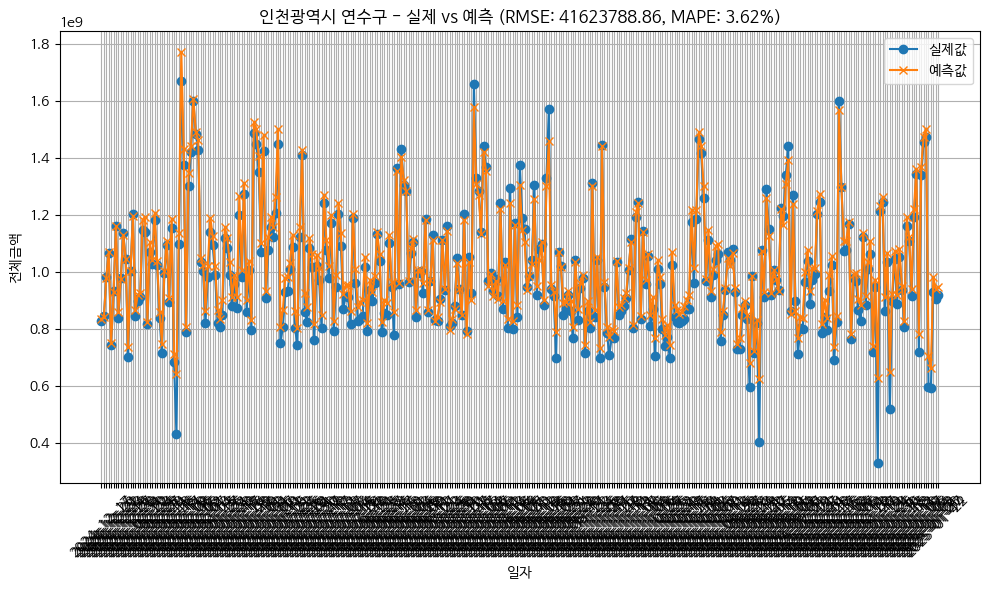

0:	learn: 7764012.1483314	test: 6788440.9715177	best: 6788440.9715177 (0)	total: 28.1ms	remaining: 28s
100:	learn: 1159301.2601268	test: 1345332.3484008	best: 1345332.3484008 (100)	total: 3.5s	remaining: 31.1s
200:	learn: 586692.9356935	test: 799702.5219773	best: 799702.5219773 (200)	total: 6.96s	remaining: 27.7s
300:	learn: 418891.0266719	test: 656485.2754096	best: 656485.2754096 (300)	total: 10.9s	remaining: 25.4s
400:	learn: 328786.9515401	test: 613921.5688459	best: 613921.5688459 (400)	total: 14.7s	remaining: 21.9s
500:	learn: 267461.8495084	test: 593362.7692105	best: 593362.7692105 (500)	total: 18.5s	remaining: 18.5s
600:	learn: 224553.9864983	test: 571412.7384780	best: 571412.7384780 (600)	total: 21.9s	remaining: 14.5s
700:	learn: 194214.6825085	test: 561688.3807155	best: 561523.0390615 (698)	total: 25.3s	remaining: 10.8s
800:	learn: 170944.3449597	test: 551461.3242639	best: 551103.8597742 (799)	total: 28.9s	remaining: 7.18s
900:	learn: 152162.7490329	test: 544290.1077141	best: 5

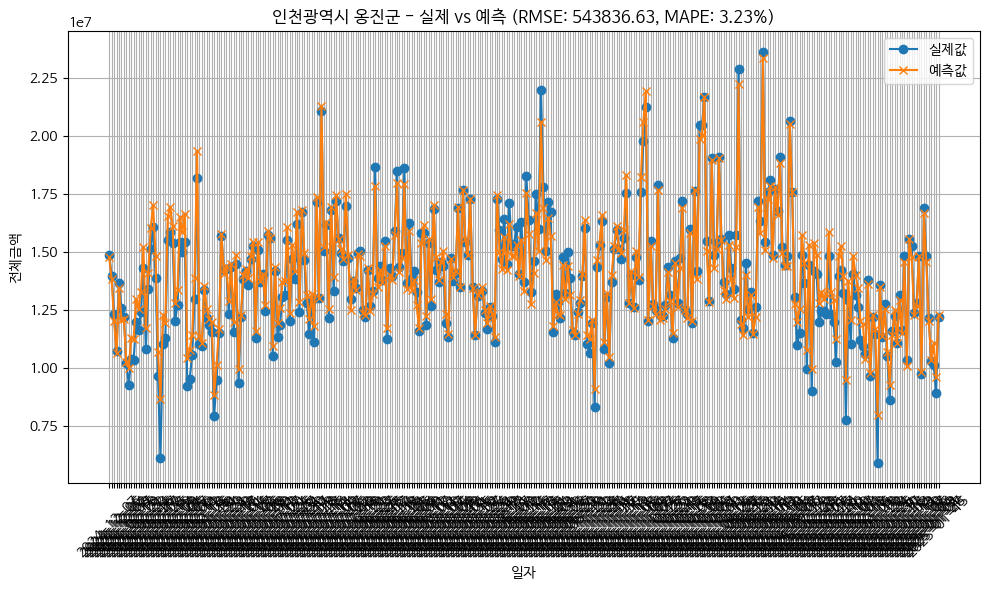

0:	learn: 188314899.8226003	test: 198047077.9981658	best: 198047077.9981658 (0)	total: 31.3ms	remaining: 31.3s
100:	learn: 29517078.8986533	test: 35381964.9253650	best: 35381964.9253650 (100)	total: 3.71s	remaining: 33s
200:	learn: 14024495.0662088	test: 18852775.5078337	best: 18852775.5078337 (200)	total: 6.95s	remaining: 27.6s
300:	learn: 10247028.2807989	test: 14434073.3487081	best: 14434073.3487081 (300)	total: 10.5s	remaining: 24.3s
400:	learn: 8107574.1067967	test: 13053071.5559075	best: 13051026.0145405 (399)	total: 14.6s	remaining: 21.8s
500:	learn: 6846159.6420063	test: 12343500.1866982	best: 12343500.1866982 (500)	total: 18s	remaining: 17.9s
600:	learn: 5948573.5129424	test: 11844913.8077285	best: 11832165.1175047 (588)	total: 22.1s	remaining: 14.7s
700:	learn: 5239591.3550255	test: 11548368.9049138	best: 11546459.7263753 (699)	total: 26.5s	remaining: 11.3s
800:	learn: 4661549.5164080	test: 11308300.5784974	best: 11299540.2306630 (794)	total: 30s	remaining: 7.46s
900:	learn: 

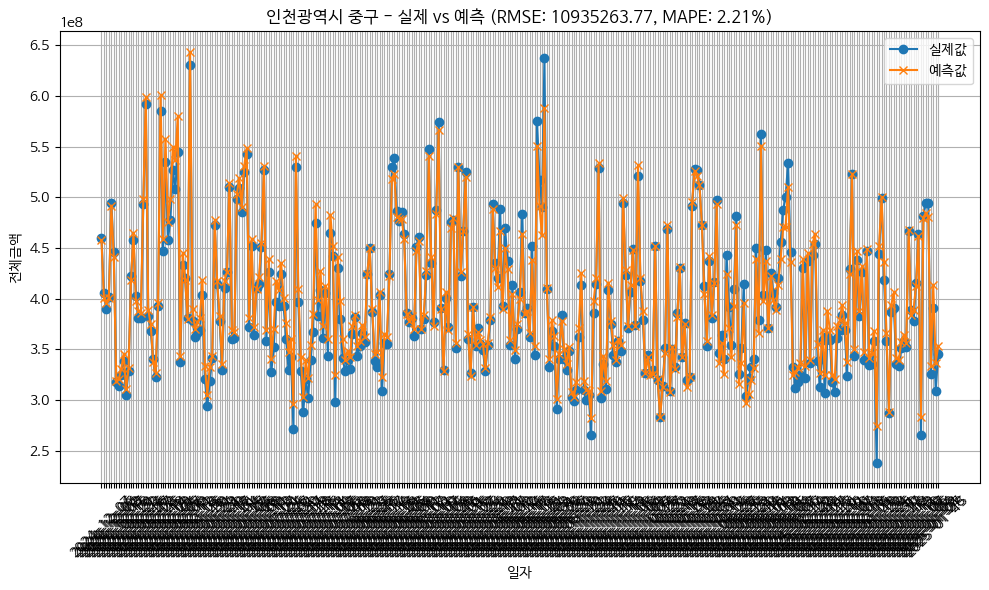

In [22]:
''''
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import matplotlib
import seaborn as sns

font_location = 'C:\\Windows\\Fonts\\Hancom Gothic Regular.ttf'
font_name = fm.FontProperties(fname=font_location).get_name()
matplotlib.rc('font', family=font_name)

# 데이터 준비
data['일자'] = pd.to_datetime(data['일자'])
data['일자'] = data['일자'].dt.to_period('D').astype(str)

# 타겟 설정
target = '전체금액'
features = [col for col in data.columns if col != target]
categorical_features = data.select_dtypes(include='object').columns.tolist()

# 지역별 모델링
for region in data['지역'].unique():
    subset = data[data['지역'] == region]

    if len(subset) < 10:
        print(f"스킵: {region} (데이터 부족)")
        continue

    X = subset[features]
    y = subset[target]

    if y.nunique() <= 1:
        print(f"스킵: {region} (타겟값 모두 동일)")
        continue

    # ✨ 일자 기준 정렬
    subset = subset.sort_values('월')
    X = subset[features]
    y = subset[target]

    # 80%/20% 기간별 분리
    split_idx = int(len(subset) * 0.8)
    X_train = X.iloc[:split_idx]
    X_valid = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_valid = y.iloc[split_idx:]

    train_pool = Pool(X_train, y_train, cat_features=categorical_features)
    valid_pool = Pool(X_valid, y_valid, cat_features=categorical_features)

    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.03,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        early_stopping_rounds=50,
        verbose=100
    )

    model.fit(train_pool, eval_set=valid_pool)

    # 예측
    y_pred = model.predict(X_valid)

    # ✨ 일자 기준 정렬
    X_valid = X_valid.copy()
    X_valid['일자'] = subset['일자'].iloc[split_idx:]
    sorted_idx = X_valid['일자'].argsort()
    X_valid = X_valid.iloc[sorted_idx]
    y_valid = y_valid.iloc[sorted_idx]
    y_pred = y_pred[sorted_idx]

    # RMSE 계산
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

    # MAPE 계산
    mape = np.mean(np.abs((y_valid - y_pred) / y_valid)) * 100

    print(f"[{region}] Validation RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

    # 시각화
    plt.figure(figsize=(10, 6))
    plt.plot(X_valid['일자'], y_valid.values, label='실제값', marker='o')
    plt.plot(X_valid['일자'], y_pred, label='예측값', marker='x')
    plt.title(f"{region} - 실제 vs 예측 (RMSE: {rmse:.2f}, MAPE: {mape:.2f}%)")
    plt.xlabel("일자")
    plt.ylabel("전체금액")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
